# Proyecto 3 — Optimización de Pricing en Rutas de Ferry

## Notebook 5 — Simulación avanzada de escenarios de pricing

En este notebook construimos un simulador avanzado de pricing para la compañía ficticia **Levante Ferries**.

El objetivo es comparar diferentes escenarios de precio y estimar su impacto en:

- Demanda esperada.
- Tickets vendidos.
- Ocupación.
- Revenue.
- Coste operativo.
- Margen.
- Riesgo comercial.
- Recomendación de pricing.

Este notebook conecta los resultados anteriores:

- Notebook 1: dataset base.
- Notebook 2: análisis exploratorio.
- Notebook 3: elasticidad precio-demanda.
- Notebook 4: modelo predictivo de demanda.
- Notebook 5: simulador de escenarios y recomendación inicial.

## 1. Objetivo del notebook

El objetivo es construir un motor de simulación que permita responder:

- ¿Qué pasaría si subimos el precio un 5%?
- ¿Qué pasaría si bajamos el precio un 10%?
- ¿Qué rutas maximizan revenue?
- ¿Qué rutas maximizan margen?
- ¿Qué escenario mantiene una ocupación saludable?
- ¿Qué viajes tienen riesgo de baja ocupación?
- ¿Qué viajes tienen riesgo de saturación?
- ¿Qué recomendación inicial de pricing podríamos hacer?

Este notebook no pretende crear una decisión automática definitiva, sino una herramienta de apoyo a decisiones de revenue management.

In [83]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob
import warnings
import joblib

from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [84]:
# ============================================================
# 2. CONEXIÓN CON GOOGLE DRIVE
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive conectado correctamente.")
except:
    print("No estás ejecutando este notebook en Google Colab o Drive ya está montado.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive conectado correctamente.


In [85]:
# ============================================================
# 3. DEFINICIÓN DE RUTAS DEL PROYECTO
# ============================================================

base_path = "/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing"

data_path = f"{base_path}/data/processed/ferry_pricing_dataset.csv"
reports_path = f"{base_path}/reports"
images_path = f"{base_path}/images"
models_path = f"{base_path}/models"

os.makedirs(reports_path, exist_ok=True)
os.makedirs(images_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

elasticity_path = f"{reports_path}/elasticity_comparison_by_route.csv"

print("Ruta base del proyecto:")
print(base_path)

print("Ruta del dataset:")
print(data_path)

print("Ruta de elasticidad:")
print(elasticity_path)

Ruta base del proyecto:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing
Ruta del dataset:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed/ferry_pricing_dataset.csv
Ruta de elasticidad:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports/elasticity_comparison_by_route.csv


## 2. Funciones auxiliares

Usaremos funciones para:

- Asegurar columnas numéricas.
- Exportar resultados en CSV estándar, CSV Excel España y XLSX.
- Cargar el modelo de demanda si existe.
- Clasificar riesgos de ocupación.
- Clasificar escenarios.
- Generar recomendaciones iniciales de pricing.

In [86]:
# ============================================================
# 4. FUNCIÓN AUXILIAR: ASEGURAR COLUMNAS NUMÉRICAS
# ============================================================

def force_numeric_columns(dataframe, columns):
    """
    Convierte columnas a formato numérico aunque vengan como texto.
    Soporta formatos como:
    - 1234.56
    - 1234,56
    - 1.234,56 €
    - 45,5 %
    """

    df_copy = dataframe.copy()

    for col in columns:
        if col not in df_copy.columns:
            continue

        direct_conversion = pd.to_numeric(df_copy[col], errors="coerce")

        if direct_conversion.notna().mean() >= 0.80:
            df_copy[col] = direct_conversion
        else:
            df_copy[col] = (
                df_copy[col]
                .astype(str)
                .str.replace("€", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.replace(" ", "", regex=False)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df_copy[col] = pd.to_numeric(df_copy[col], errors="coerce")

    return df_copy


print("Función force_numeric_columns creada correctamente.")

Función force_numeric_columns creada correctamente.


In [87]:
# ============================================================
# 5. FUNCIÓN DE EXPORTACIÓN: CSV NORMAL + CSV EXCEL ES + XLSX
# ============================================================

def export_table_files(dataframe, output_folder, file_name, sheet_name="Data"):
    """
    Exporta un DataFrame en tres formatos:

    1. CSV estándar para Python.
    2. CSV compatible con Excel España: separador ; y decimal ,
    3. XLSX con formato numérico.
    """

    os.makedirs(output_folder, exist_ok=True)

    csv_path = f"{output_folder}/{file_name}.csv"
    csv_excel_es_path = f"{output_folder}/{file_name}_excel_es.csv"
    xlsx_path = f"{output_folder}/{file_name}.xlsx"

    df_export = dataframe.copy()

    for col in df_export.columns:
        if pd.api.types.is_datetime64_any_dtype(df_export[col]):
            df_export[col] = df_export[col].dt.strftime("%d/%m/%Y %H:%M")

    dataframe.to_csv(csv_path, index=False, encoding="utf-8-sig")

    df_export.to_csv(
        csv_excel_es_path,
        index=False,
        sep=";",
        decimal=",",
        encoding="utf-8-sig"
    )

    safe_sheet_name = sheet_name[:31]

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        dataframe.to_excel(writer, index=False, sheet_name=safe_sheet_name)

        worksheet = writer.sheets[safe_sheet_name]
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions

        for cell in worksheet[1]:
            cell.font = Font(bold=True)

        for col_idx, col_name in enumerate(dataframe.columns, start=1):
            column_letter = get_column_letter(col_idx)

            if pd.api.types.is_float_dtype(dataframe[col_name]):
                if col_name in [
                    "occupancy_rate", "current_occupancy_rate", "simulated_occupancy_rate",
                    "avg_occupancy", "avg_current_occupancy", "avg_simulated_occupancy",
                    "margin_pct", "simulated_margin_pct", "avg_margin_pct",
                    "price_change_pct", "demand_change_pct", "tickets_change_pct",
                    "revenue_uplift_pct", "margin_uplift_pct", "risk_score"
                ]:
                    number_format = "0.00%"
                else:
                    number_format = "0.00"

                for cell in worksheet[column_letter][1:]:
                    cell.number_format = number_format

            elif pd.api.types.is_integer_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "0"

            elif pd.api.types.is_datetime64_any_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "DD/MM/YYYY HH:MM"

        for column_cells in worksheet.columns:
            max_length = 0
            column_letter = get_column_letter(column_cells[0].column)

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            adjusted_width = min(max_length + 2, 40)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"Exportado: {file_name}")


print("Función export_table_files creada correctamente.")

Función export_table_files creada correctamente.


In [88]:
# ============================================================
# 6. FUNCIONES DE RIESGO Y RECOMENDACIÓN
# ============================================================

def find_latest_model(models_folder):
    """
    Busca el último modelo .joblib disponible en la carpeta models.
    """

    model_files = glob.glob(f"{models_folder}/demand_prediction_model_*.joblib")

    if len(model_files) == 0:
        return None

    latest_model = max(model_files, key=os.path.getmtime)
    return latest_model


def classify_occupancy_risk(occupancy):
    """
    Clasifica riesgo de ocupación.
    """

    if occupancy >= 0.95:
        return "Saturation risk"
    elif occupancy >= 0.85:
        return "High occupancy"
    elif occupancy >= 0.65:
        return "Healthy occupancy"
    elif occupancy >= 0.50:
        return "Soft demand"
    else:
        return "Low occupancy risk"


def classify_margin_health(margin_pct):
    """
    Clasifica salud de margen.
    """

    if margin_pct >= 0.35:
        return "Very strong margin"
    elif margin_pct >= 0.25:
        return "Healthy margin"
    elif margin_pct >= 0.15:
        return "Weak margin"
    else:
        return "Margin pressure"


def classify_price_position(price_index):
    """
    Clasifica posicionamiento frente a competidor.
    """

    if price_index >= 1.12:
        return "Premium vs competitor"
    elif price_index >= 1.03:
        return "Slightly above competitor"
    elif price_index >= 0.97:
        return "Market aligned"
    elif price_index >= 0.90:
        return "Slightly below competitor"
    else:
        return "Discounted vs competitor"


def pricing_action(row):
    """
    Genera una recomendación inicial por viaje y escenario.
    """

    elasticity = row["elasticity_for_simulation"]
    simulated_occupancy = row["simulated_occupancy_rate"]
    simulated_margin_pct = row["simulated_margin_pct"]
    price_index = row["simulated_price_index_vs_competitor"]
    price_change = row["price_change_pct"]

    if (
        price_change > 0
        and simulated_occupancy >= 0.80
        and simulated_margin_pct >= 0.25
        and elasticity > -1
        and price_index <= 1.12
    ):
        return "Candidate for controlled increase"

    elif (
        price_change < 0
        and simulated_occupancy < 0.65
        and elasticity <= -1
    ):
        return "Candidate for promotion"

    elif (
        simulated_occupancy >= 0.92
        and price_index > 1.12
    ):
        return "High demand but premium risk"

    elif simulated_margin_pct < 0.15:
        return "Review margin pressure"

    elif (
        0.65 <= simulated_occupancy < 0.90
        and simulated_margin_pct >= 0.20
    ):
        return "Maintain / monitor"

    else:
        return "Manual review"


def scenario_business_label(row):
    """
    Etiqueta ejecutiva para resumen agregado de escenarios.
    """

    if row["revenue_uplift_pct"] > 0.03 and row["margin_uplift_pct"] > 0.03:
        return "Revenue and margin improvement"
    elif row["revenue_uplift_pct"] > 0.03 and row["margin_uplift_pct"] <= 0:
        return "Revenue improvement but margin risk"
    elif row["revenue_uplift_pct"] <= 0 and row["margin_uplift_pct"] > 0.03:
        return "Margin improvement but revenue risk"
    elif row["revenue_uplift_pct"] < -0.03 or row["margin_uplift_pct"] < -0.03:
        return "Negative impact"
    else:
        return "Neutral impact"


print("Funciones de riesgo y recomendación creadas correctamente.")

Funciones de riesgo y recomendación creadas correctamente.


## 3. Carga del dataset y resultados previos

Cargamos:

1. Dataset principal.
2. Elasticidad por ruta del Notebook 3.
3. Modelo de demanda del Notebook 4, si está disponible.

Si el modelo de demanda no está disponible, el notebook sigue funcionando usando `tickets_sold` como demanda base observada.

In [89]:
# ============================================================
# 7. CARGA DEL DATASET PRINCIPAL
# ============================================================

df = pd.read_csv(data_path, parse_dates=["trip_date", "departure_datetime"])

print("Dataset principal cargado correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Dataset principal cargado correctamente.
Filas: 5,475
Columnas: 38


,trip_id,trip_date,departure_datetime,year,month,week,day_of_week,is_weekend,season,high_season_flag,route,origin,destination,route_type,vessel_type,departure_hour,capacity,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor,route_elasticity,days_before_departure,booking_window,weather_score,event_flag,expected_demand,tickets_sold,occupancy_rate,revenue,fixed_operational_cost,variable_cost_per_passenger,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity,trip_feature
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,8,350,58,44.7600,42.0200,1.0650,-0.8500,50,Early,7.9000,0,189,189,0.5400,"8,459.6400",14500,8,16012,"-7,552.3600",-0.8928,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,14,350,58,57.3500,57.2600,1.0020,-0.8500,34,Medium,7.0000,0,160,160,0.4571,"9,176.0000",14500,8,15780,"-6,604.0000",-0.7197,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,20,350,58,56.7800,62.5200,0.9080,-0.8500,9,Short,8.1000,0,195,195,0.5571,"11,072.1000",14500,8,16060,"-4,987.9000",-0.4505,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,9,280,72,66.9300,66.9800,0.9990,-0.7500,24,Medium,9.3000,0,160,160,0.5714,"10,708.8000",13200,7,14320,"-3,611.2000",-0.3372,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,17,280,72,64.1600,63.4100,1.0120,-0.7500,36,Medium,6.9000,0,131,131,0.4679,"8,404.9600",13200,7,14117,"-5,712.0400",-0.6796,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [90]:
# ============================================================
# 8. ASEGURAR TIPOS NUMÉRICOS
# ============================================================

numeric_columns_to_check = [
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "weather_score",
    "event_flag",
    "expected_demand",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "fixed_operational_cost",
    "variable_cost_per_passenger",
    "total_operational_cost",
    "margin",
    "margin_pct"
]

df = force_numeric_columns(df, numeric_columns_to_check)

print("Columnas numéricas revisadas correctamente.")
df[numeric_columns_to_check].dtypes

Columnas numéricas revisadas correctamente.


,0
capacity,int64
base_price,int64
avg_ticket_price,float64
competitor_price,float64
price_index_vs_competitor,float64
route_elasticity,float64
days_before_departure,int64
weather_score,float64
event_flag,int64
expected_demand,int64


In [91]:
# ============================================================
# 9. CARGA DE ELASTICIDAD DEL NOTEBOOK 3
# ============================================================

if os.path.exists(elasticity_path):
    elasticity_df = pd.read_csv(elasticity_path)
    print("Archivo de elasticidad cargado correctamente.")
else:
    print("No se encuentra elasticity_comparison_by_route.csv. Se usará route_elasticity del dataset como fallback.")
    elasticity_df = df[["route", "route_elasticity"]].drop_duplicates().copy()
    elasticity_df["elasticity_for_simulation"] = elasticity_df["route_elasticity"]

elasticity_numeric_cols = [
    "simple_elasticity",
    "adjusted_elasticity",
    "simulated_route_elasticity",
    "elasticity_for_simulation",
    "avg_occupancy",
    "avg_margin_pct",
    "avg_price_index"
]

elasticity_df = force_numeric_columns(elasticity_df, elasticity_numeric_cols)

elasticity_df.head()

Archivo de elasticidad cargado correctamente.


,route,simple_elasticity,simple_r2,price_demand_corr,adjusted_elasticity,adjusted_r2,simulated_route_elasticity,avg_price_index,avg_ticket_price,avg_occupancy,total_revenue,total_margin,avg_margin_pct,elasticity_for_simulation,elasticity_class,business_interpretation
0,Valencia-Mallorca,0.2752,0.0465,0.2090,-1.1114,0.7075,-1.0500,1.0249,66.2569,0.5882,"30,124,521.7700","-5,398,010.2300",-0.2868,-1.1114,Unit elastic area,Demand is close to unit elasticity. Price chan...
1,Ibiza-Mallorca,0.1789,0.0246,0.1545,-1.0752,0.6332,-1.1500,1.0248,52.3318,0.6080,"10,510,459.1000","-3,808,748.9000",-0.4664,-1.0752,Unit elastic area,Demand is close to unit elasticity. Price chan...
2,Valencia-Ibiza,0.3984,0.0923,0.3102,-0.9541,0.7381,-0.9000,1.0224,74.1938,0.5857,"19,932,754.2000","-1,598,389.8000",-0.1934,-0.9541,Inelastic,Demand is relatively inelastic. Controlled pri...
3,Denia-Mallorca,0.4657,0.1498,0.3911,-0.8472,0.6885,-0.9500,1.0274,68.5058,0.5332,"14,072,473.8100","-4,376,746.1900",-0.4391,-0.8472,Inelastic,Demand is relatively inelastic. Controlled pri...
4,Denia-Ibiza,0.4448,0.1303,0.3666,-0.8359,0.6777,-0.8500,1.0270,62.0796,0.7270,"17,529,547.3700","-576,840.6300",-0.1313,-0.8359,Inelastic,Demand is relatively inelastic. Controlled pri...


In [92]:
# ============================================================
# 10. CARGA DEL MODELO DE DEMANDA DEL NOTEBOOK 4
# ============================================================

latest_model_path = find_latest_model(models_path)

if latest_model_path is not None:
    demand_model = joblib.load(latest_model_path)
    model_available = True
    print("Modelo de demanda cargado correctamente:")
    print(latest_model_path)
else:
    demand_model = None
    model_available = False
    print("No se ha encontrado modelo de demanda. Se usará la demanda observada como base.")

Modelo de demanda cargado correctamente:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/models/demand_prediction_model_Ridge_Regression.joblib


## 4. Preparación de la demanda base

Para simular escenarios necesitamos una demanda base.

Orden de preferencia:

1. Si existe modelo del Notebook 4, usamos `predicted_base_demand`.
2. Si no existe modelo, usamos `tickets_sold`.

Después limitamos la demanda entre 0 y la capacidad del ferry.

In [93]:
# ============================================================
# 11. FEATURES DEL MODELO DE DEMANDA
# ============================================================

numeric_features = [
    "month",
    "week",
    "departure_hour",
    "is_weekend",
    "high_season_flag",
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "weather_score",
    "event_flag"
]

categorical_features = [
    "route",
    "origin",
    "destination",
    "route_type",
    "vessel_type",
    "day_of_week",
    "season",
    "booking_window"
]

feature_columns = numeric_features + categorical_features

missing_features = [col for col in feature_columns if col not in df.columns]

if len(missing_features) > 0:
    print("Faltan columnas para el modelo:")
    print(missing_features)
else:
    print("Todas las features del modelo están disponibles.")

Todas las features del modelo están disponibles.


In [94]:
# ============================================================
# 12. CREACIÓN DE DEMANDA BASE
# ============================================================

simulation_base = df.copy()

if model_available and len(missing_features) == 0:

    X_all = simulation_base[feature_columns].copy()
    predicted_base_demand = demand_model.predict(X_all)

    simulation_base["base_demand_for_simulation"] = np.minimum(
        np.maximum(predicted_base_demand, 0),
        simulation_base["capacity"]
    )

    simulation_base["base_demand_source"] = "Demand model"

else:

    simulation_base["base_demand_for_simulation"] = simulation_base["tickets_sold"]
    simulation_base["base_demand_source"] = "Observed tickets"

simulation_base["base_occupancy_for_simulation"] = (
    simulation_base["base_demand_for_simulation"] / simulation_base["capacity"]
)

print("Demanda base preparada correctamente.")
simulation_base[[
    "trip_id",
    "route",
    "avg_ticket_price",
    "tickets_sold",
    "base_demand_for_simulation",
    "base_occupancy_for_simulation",
    "base_demand_source"
]].head()

Demanda base preparada correctamente.


,trip_id,route,avg_ticket_price,tickets_sold,base_demand_for_simulation,base_occupancy_for_simulation,base_demand_source
0,TRIP_000001,Denia-Ibiza,44.7600,189,262.5137,0.7500,Demand model
1,TRIP_000002,Denia-Ibiza,57.3500,160,190.4919,0.5443,Demand model
2,TRIP_000003,Denia-Ibiza,56.7800,195,176.3853,0.5040,Demand model
3,TRIP_000004,Denia-Formentera,66.9300,160,175.9420,0.6284,Demand model
4,TRIP_000005,Denia-Formentera,64.1600,131,135.3458,0.4834,Demand model


In [95]:
# ============================================================
# 13. AÑADIR ELASTICIDAD POR RUTA
# ============================================================

elasticity_map = dict(
    zip(
        elasticity_df["route"],
        elasticity_df["elasticity_for_simulation"]
    )
)

simulation_base["elasticity_for_simulation"] = simulation_base["route"].map(elasticity_map)

simulation_base["elasticity_for_simulation"] = simulation_base["elasticity_for_simulation"].fillna(
    simulation_base["route_elasticity"]
)

simulation_base[[
    "route",
    "route_elasticity",
    "elasticity_for_simulation"
]].drop_duplicates().sort_values("route")

,route,route_elasticity,elasticity_for_simulation
3,Denia-Formentera,-0.7500,-0.7788
0,Denia-Ibiza,-0.8500,-0.8359
5,Denia-Mallorca,-0.9500,-0.8472
12,Ibiza-Mallorca,-1.1500,-1.0752
7,Valencia-Ibiza,-0.9000,-0.9541
9,Valencia-Mallorca,-1.0500,-1.1114


## 5. KPIs base antes de simular

Calculamos la foto inicial antes de probar escenarios.

Estos KPIs serán el punto de comparación para medir uplift o pérdida.

In [96]:
# ============================================================
# 14. KPIS BASE
# ============================================================

base_total_trips = simulation_base["trip_id"].nunique()
base_total_tickets = simulation_base["base_demand_for_simulation"].sum()
base_total_revenue = simulation_base["revenue"].sum()
base_total_margin = simulation_base["margin"].sum()
base_avg_occupancy = simulation_base["base_occupancy_for_simulation"].mean()
base_avg_price = simulation_base["avg_ticket_price"].mean()
base_avg_margin_pct = simulation_base["margin_pct"].mean()

print("KPIs BASE PARA SIMULACIÓN")
print("-" * 50)
print(f"Viajes: {base_total_trips:,.0f}")
print(f"Demanda base: {base_total_tickets:,.0f}")
print(f"Revenue actual: {base_total_revenue:,.2f} €")
print(f"Margen actual: {base_total_margin:,.2f} €")
print(f"Ocupación base media: {base_avg_occupancy:.2%}")
print(f"Precio medio actual: {base_avg_price:.2f} €")
print(f"Margen porcentual medio: {base_avg_margin_pct:.2%}")
print(f"Fuente demanda base: {simulation_base['base_demand_source'].iloc[0]}")

KPIs BASE PARA SIMULACIÓN
--------------------------------------------------
Viajes: 5,475
Demanda base: 1,531,316
Revenue actual: 102,998,839.77 €
Margen actual: -15,536,685.23 €
Ocupación base media: 62.08%
Precio medio actual: 65.39 €
Margen porcentual medio: -27.23%
Fuente demanda base: Demand model


## 6. Definición de escenarios

Simulamos escenarios de precio desde -20% hasta +20%.

Además de escenarios generales, en notebooks posteriores podremos crear escenarios más segmentados por ruta, temporada o ventana de reserva.

In [97]:
# ============================================================
# 15. DEFINICIÓN DE ESCENARIOS DE PRECIO
# ============================================================

price_scenarios = [-0.20, -0.15, -0.10, -0.05, 0.00, 0.05, 0.10, 0.15, 0.20]

scenario_config = pd.DataFrame({
    "price_change_pct": price_scenarios,
    "scenario_label": [f"{x:+.0%}" for x in price_scenarios]
})

scenario_config["scenario_type"] = np.where(
    scenario_config["price_change_pct"] < 0,
    "Discount",
    np.where(
        scenario_config["price_change_pct"] > 0,
        "Increase",
        "Current"
    )
)

scenario_config

,price_change_pct,scenario_label,scenario_type
0,-0.2000,-20%,Discount
1,-0.1500,-15%,Discount
2,-0.1000,-10%,Discount
3,-0.0500,-5%,Discount
4,0.0000,+0%,Current
5,0.0500,+5%,Increase
6,0.1000,+10%,Increase
7,0.1500,+15%,Increase
8,0.2000,+20%,Increase


## 7. Simulación avanzada por viaje

Para cada viaje y cada escenario calculamos:

- Precio simulado.
- Demanda simulada.
- Tickets simulados limitados por capacidad.
- Ocupación simulada.
- Revenue simulado.
- Coste operativo simulado.
- Margen simulado.
- Riesgo de ocupación.
- Salud de margen.
- Posición frente a competidor.
- Acción recomendada.

Usaremos la fórmula de elasticidad:

`demanda simulada = demanda base * (precio simulado / precio actual) ^ elasticidad`

In [121]:
# ============================================================
# 16. MOTOR DE SIMULACIÓN POR VIAJE
# ============================================================

scenario_frames = []

for _, scenario_row in scenario_config.iterrows():

    price_change = scenario_row["price_change_pct"]
    scenario_label = scenario_row["scenario_label"]
    scenario_type = scenario_row["scenario_type"]

    temp = simulation_base.copy()

    temp["scenario_label"] = scenario_label
    temp["scenario_type"] = scenario_type
    temp["price_change_pct"] = price_change

    temp["simulated_ticket_price"] = temp["avg_ticket_price"] * (1 + price_change)

    temp["simulated_price_index_vs_competitor"] = (
        temp["simulated_ticket_price"] / temp["competitor_price"]
    )

    temp["simulated_demand"] = (
        temp["base_demand_for_simulation"] *
        ((temp["simulated_ticket_price"] / temp["avg_ticket_price"]) ** temp["elasticity_for_simulation"])
    )

    temp["simulated_tickets_sold"] = np.minimum(
        np.maximum(temp["simulated_demand"], 0),
        temp["capacity"]
    )

    temp["simulated_occupancy_rate"] = temp["simulated_tickets_sold"] / temp["capacity"]

    temp["simulated_revenue"] = (
        temp["simulated_tickets_sold"] * temp["simulated_ticket_price"]
    )

    temp["simulated_operational_cost"] = (
        temp["fixed_operational_cost"] +
        temp["simulated_tickets_sold"] * temp["variable_cost_per_passenger"]
    )

    temp["simulated_margin"] = (
        temp["simulated_revenue"] - temp["simulated_operational_cost"]
    )

    temp["simulated_margin_pct"] = np.where(
        temp["simulated_revenue"] > 0,
        temp["simulated_margin"] / temp["simulated_revenue"],
        0
    )

    temp["demand_change"] = (
        temp["simulated_tickets_sold"] - temp["base_demand_for_simulation"]
    )

    temp["demand_change_pct"] = np.where(
        temp["base_demand_for_simulation"] > 0,
        temp["demand_change"] / temp["base_demand_for_simulation"],
        0
    )

    temp["revenue_uplift"] = temp["simulated_revenue"] - temp["revenue"]

    temp["revenue_uplift_pct"] = np.where(
        temp["revenue"] > 0,
        temp["revenue_uplift"] / temp["revenue"],
        0
    )

    temp["margin_uplift"] = temp["simulated_margin"] - temp["margin"]

    temp["margin_uplift_pct"] = np.where(
        temp["margin"] != 0,
        temp["margin_uplift"] / temp["margin"],
        0
    )

    temp["occupancy_risk"] = temp["simulated_occupancy_rate"].apply(classify_occupancy_risk)
    temp["margin_health"] = temp["simulated_margin_pct"].apply(classify_margin_health)
    temp["price_position"] = temp["simulated_price_index_vs_competitor"].apply(classify_price_position)

    scenario_frames.append(temp)

simulation_detail = pd.concat(scenario_frames, ignore_index=True)

simulation_detail["pricing_action"] = simulation_detail.apply(pricing_action, axis=1)

print(f"Filas simuladas: {simulation_detail.shape[0]:,}")
simulation_detail[[
    "trip_id",
    "route",
    "scenario_label",
    "price_change_pct",
    "avg_ticket_price",
    "simulated_ticket_price",
    "base_demand_for_simulation",
    "simulated_tickets_sold",
    "simulated_occupancy_rate",
    "simulated_revenue",
    "simulated_margin",
    "pricing_action"
]].head()

Filas simuladas: 49,275


,trip_id,route,scenario_label,price_change_pct,avg_ticket_price,simulated_ticket_price,base_demand_for_simulation,simulated_tickets_sold,simulated_occupancy_rate,simulated_revenue,simulated_margin,pricing_action
0,TRIP_000001,Denia-Ibiza,-20%,-0.2000,44.7600,35.8080,262.5137,316.3415,0.9038,"11,327.5575","-5,703.1747",Review margin pressure
1,TRIP_000002,Denia-Ibiza,-20%,-0.2000,57.3500,45.8800,190.4919,229.5519,0.6559,"10,531.8399","-5,804.5751",Review margin pressure
2,TRIP_000003,Denia-Ibiza,-20%,-0.2000,56.7800,45.4240,176.3853,212.5527,0.6073,"9,654.9954","-6,545.4264",Review margin pressure
3,TRIP_000004,Denia-Formentera,-20%,-0.2000,66.9300,53.5440,175.9420,209.3349,0.7476,"11,208.6275","-3,456.7167",Review margin pressure
4,TRIP_000005,Denia-Formentera,-20%,-0.2000,64.1600,51.3280,135.3458,161.0337,0.5751,"8,265.5396","-6,061.6965",Review margin pressure


## 8. Resumen global por escenario

Agregamos todos los viajes por escenario para ver el impacto global en la compañía.

In [99]:
# ============================================================
# 17. RESUMEN GLOBAL POR ESCENARIO
# ============================================================

scenario_global_summary = (
    simulation_detail
    .groupby(["scenario_label", "scenario_type", "price_change_pct"])
    .agg(
        trips=("trip_id", "count"),
        simulated_tickets=("simulated_tickets_sold", "sum"),
        simulated_revenue=("simulated_revenue", "sum"),
        simulated_margin=("simulated_margin", "sum"),
        avg_simulated_occupancy=("simulated_occupancy_rate", "mean"),
        avg_simulated_price=("simulated_ticket_price", "mean"),
        avg_simulated_margin_pct=("simulated_margin_pct", "mean")
    )
    .reset_index()
    .sort_values("price_change_pct")
)

scenario_global_summary["current_revenue"] = base_total_revenue
scenario_global_summary["current_margin"] = base_total_margin
scenario_global_summary["current_tickets"] = base_total_tickets

scenario_global_summary["revenue_uplift"] = (
    scenario_global_summary["simulated_revenue"] - scenario_global_summary["current_revenue"]
)

scenario_global_summary["revenue_uplift_pct"] = (
    scenario_global_summary["revenue_uplift"] / scenario_global_summary["current_revenue"]
)

scenario_global_summary["margin_uplift"] = (
    scenario_global_summary["simulated_margin"] - scenario_global_summary["current_margin"]
)

scenario_global_summary["margin_uplift_pct"] = np.where(
    scenario_global_summary["current_margin"] != 0,
    scenario_global_summary["margin_uplift"] / scenario_global_summary["current_margin"],
    0
)

scenario_global_summary["tickets_change"] = (
    scenario_global_summary["simulated_tickets"] - scenario_global_summary["current_tickets"]
)

scenario_global_summary["tickets_change_pct"] = (
    scenario_global_summary["tickets_change"] / scenario_global_summary["current_tickets"]
)

scenario_global_summary["business_label"] = scenario_global_summary.apply(scenario_business_label, axis=1)

scenario_global_summary

,scenario_label,scenario_type,price_change_pct,trips,simulated_tickets,simulated_revenue,simulated_margin,avg_simulated_occupancy,avg_simulated_price,avg_simulated_margin_pct,current_revenue,current_margin,current_tickets,revenue_uplift,revenue_uplift_pct,margin_uplift,margin_uplift_pct,tickets_change,tickets_change_pct,business_label
7,-20%,Discount,-0.2000,5475,"1,886,346.9240","101,198,464.3389","-20,872,683.1396",0.7586,52.3094,-0.3395,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","-1,800,375.4311",-0.0175,"-5,335,997.9096",0.3434,"355,031.1470",0.2318,Margin improvement but revenue risk
6,-15%,Discount,-0.1500,5475,"1,785,343.5432","101,813,091.5909","-19,238,547.3624",0.7200,55.5787,-0.3228,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","-1,185,748.1791",-0.0115,"-3,701,862.1324",0.2383,"254,027.7662",0.1659,Margin improvement but revenue risk
5,-10%,Discount,-0.1000,5475,"1,692,732.5407","102,252,271.0584","-17,872,363.0822",0.6841,58.8480,-0.3090,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","-746,568.7116",-0.0072,"-2,335,677.8522",0.1503,"161,416.7637",0.1054,Margin improvement but revenue risk
8,-5%,Discount,-0.0500,5475,"1,608,243.7632","102,581,437.0706","-16,701,986.4143",0.6511,62.1174,-0.2972,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","-417,402.6994",-0.0041,"-1,165,301.1843",0.0750,"76,927.9861",0.0502,Margin improvement but revenue risk
0,+0%,Current,0.0000,5475,"1,531,315.7771","102,845,595.7887","-15,674,450.1982",0.6208,65.3867,-0.2868,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","-153,243.9813",-0.0015,"-137,764.9682",0.0089,0.0000,0.0000,Neutral impact
4,+5%,Increase,0.0500,5475,"1,460,946.8266","103,050,407.9251","-14,773,476.8581",0.5929,68.6560,-0.2776,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","51,568.1551",0.0005,"763,208.3719",-0.0491,"-70,368.9505",-0.0460,Negative impact
1,+10%,Increase,0.1000,5475,"1,396,914.8486","103,249,698.6564","-13,941,125.2939",0.5675,71.9254,-0.2691,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","250,858.8864",0.0024,"1,595,559.9361",-0.1027,"-134,400.9285",-0.0878,Negative impact
2,+15%,Increase,0.1500,5475,"1,338,396.4252","103,443,803.8485","-13,168,826.9009",0.5443,75.1947,-0.2613,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","444,964.0785",0.0043,"2,367,858.3291",-0.1524,"-192,919.3519",-0.1260,Negative impact
3,+20%,Increase,0.2000,5475,"1,284,705.1412","103,633,028.8151","-12,449,417.4317",0.5230,78.4640,-0.2542,"102,998,839.7700","-15,536,685.2300","1,531,315.7771","634,189.0451",0.0062,"3,087,267.7983",-0.1987,"-246,610.6359",-0.1610,Negative impact


## 9. Visualización global de escenarios

Primero analizamos el impacto global en revenue y margen.

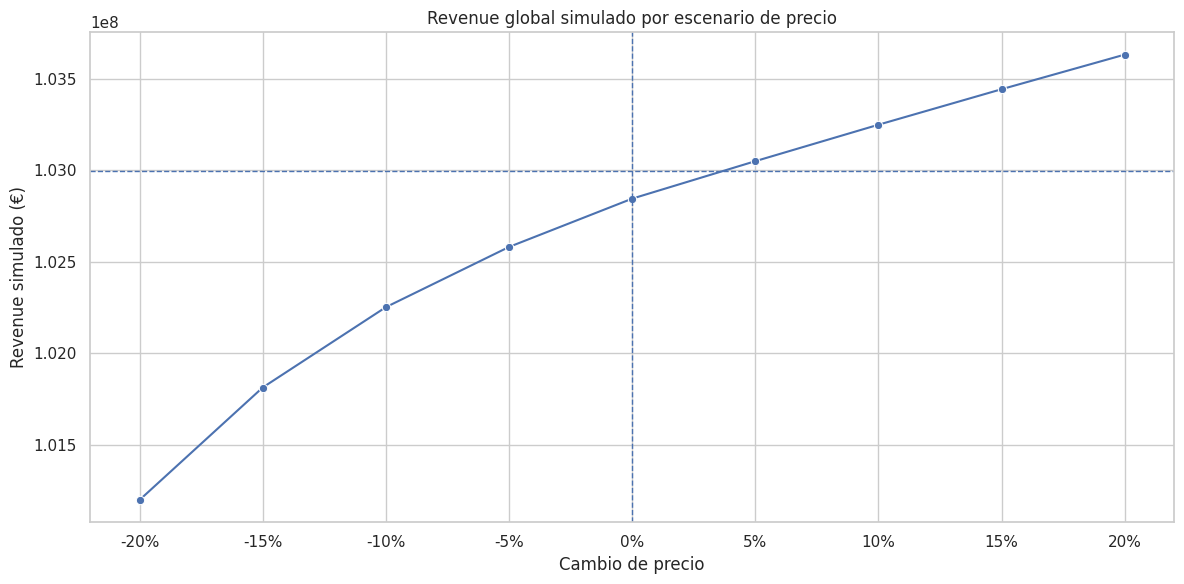

In [100]:
# ============================================================
# 18. GRÁFICO: REVENUE GLOBAL POR ESCENARIO
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=scenario_global_summary,
    x="price_change_pct",
    y="simulated_revenue",
    marker="o"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(base_total_revenue, linestyle="--", linewidth=1)

plt.title("Revenue global simulado por escenario de precio")
plt.xlabel("Cambio de precio")
plt.ylabel("Revenue simulado (€)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()

plt.savefig(f"{images_path}/33_global_revenue_by_price_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

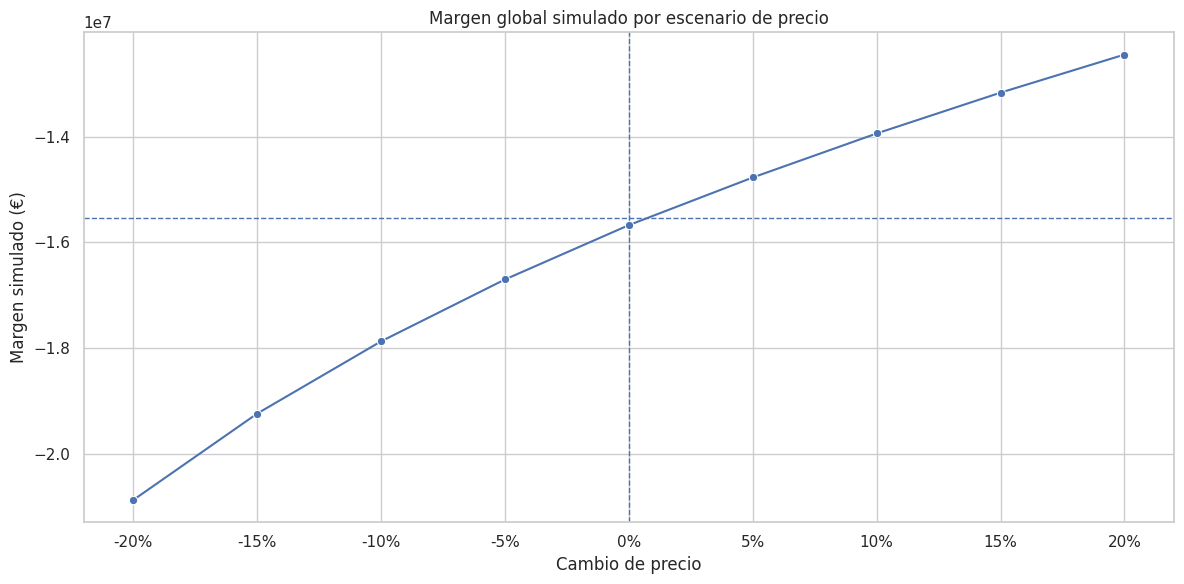

In [101]:
# ============================================================
# 19. GRÁFICO: MARGEN GLOBAL POR ESCENARIO
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=scenario_global_summary,
    x="price_change_pct",
    y="simulated_margin",
    marker="o"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(base_total_margin, linestyle="--", linewidth=1)

plt.title("Margen global simulado por escenario de precio")
plt.xlabel("Cambio de precio")
plt.ylabel("Margen simulado (€)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()

plt.savefig(f"{images_path}/34_global_margin_by_price_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

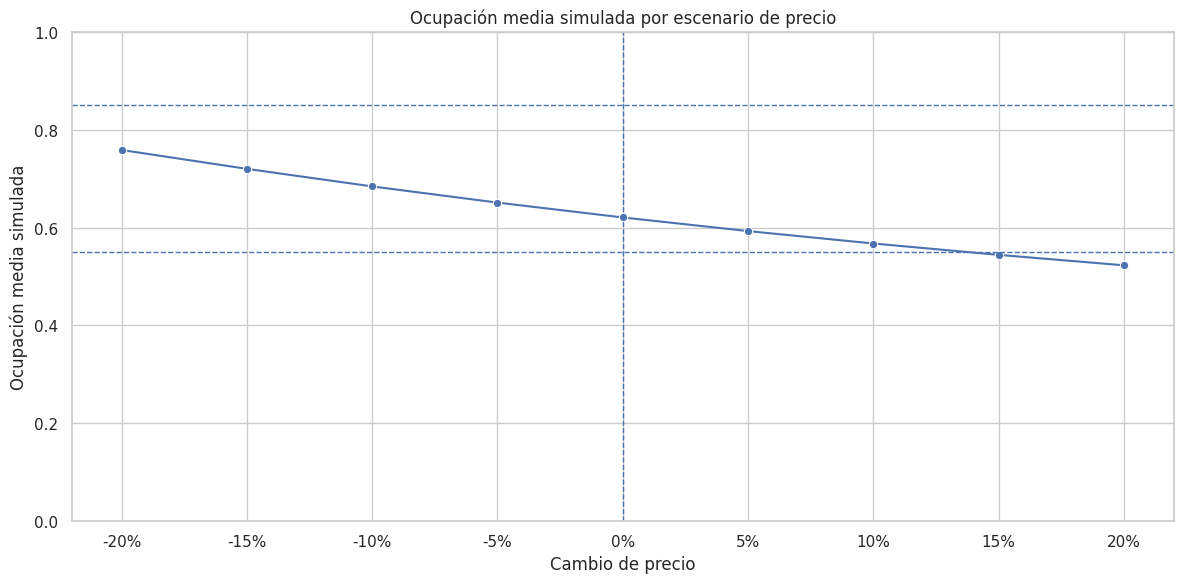

In [102]:
# ============================================================
# 20. GRÁFICO: OCUPACIÓN GLOBAL POR ESCENARIO
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=scenario_global_summary,
    x="price_change_pct",
    y="avg_simulated_occupancy",
    marker="o"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0.85, linestyle="--", linewidth=1)
plt.axhline(0.55, linestyle="--", linewidth=1)

plt.title("Ocupación media simulada por escenario de precio")
plt.xlabel("Cambio de precio")
plt.ylabel("Ocupación media simulada")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(f"{images_path}/35_global_occupancy_by_price_scenario.png", dpi=300, bbox_inches="tight")

plt.show()

## 10. Resumen por ruta y escenario

Ahora agregamos por ruta.

Este bloque es clave porque una estrategia de pricing global puede no funcionar igual para todas las rutas.

In [103]:
# ============================================================
# 21. RESUMEN POR RUTA Y ESCENARIO
# ============================================================

route_scenario_summary = (
    simulation_detail
    .groupby(["route", "scenario_label", "scenario_type", "price_change_pct"])
    .agg(
        trips=("trip_id", "count"),
        current_tickets=("base_demand_for_simulation", "sum"),
        simulated_tickets=("simulated_tickets_sold", "sum"),
        current_revenue=("revenue", "sum"),
        simulated_revenue=("simulated_revenue", "sum"),
        current_margin=("margin", "sum"),
        simulated_margin=("simulated_margin", "sum"),
        avg_current_occupancy=("base_occupancy_for_simulation", "mean"),
        avg_simulated_occupancy=("simulated_occupancy_rate", "mean"),
        avg_current_price=("avg_ticket_price", "mean"),
        avg_simulated_price=("simulated_ticket_price", "mean"),
        avg_simulated_margin_pct=("simulated_margin_pct", "mean"),
        avg_elasticity=("elasticity_for_simulation", "mean")
    )
    .reset_index()
)

route_scenario_summary["revenue_uplift"] = (
    route_scenario_summary["simulated_revenue"] - route_scenario_summary["current_revenue"]
)

route_scenario_summary["revenue_uplift_pct"] = np.where(
    route_scenario_summary["current_revenue"] > 0,
    route_scenario_summary["revenue_uplift"] / route_scenario_summary["current_revenue"],
    0
)

route_scenario_summary["margin_uplift"] = (
    route_scenario_summary["simulated_margin"] - route_scenario_summary["current_margin"]
)

route_scenario_summary["margin_uplift_pct"] = np.where(
    route_scenario_summary["current_margin"] != 0,
    route_scenario_summary["margin_uplift"] / route_scenario_summary["current_margin"],
    0
)

route_scenario_summary["tickets_change"] = (
    route_scenario_summary["simulated_tickets"] - route_scenario_summary["current_tickets"]
)

route_scenario_summary["tickets_change_pct"] = np.where(
    route_scenario_summary["current_tickets"] > 0,
    route_scenario_summary["tickets_change"] / route_scenario_summary["current_tickets"],
    0
)

route_scenario_summary["business_label"] = route_scenario_summary.apply(scenario_business_label, axis=1)

route_scenario_summary.head()

,route,scenario_label,scenario_type,price_change_pct,trips,current_tickets,simulated_tickets,current_revenue,simulated_revenue,current_margin,simulated_margin,avg_current_occupancy,avg_simulated_occupancy,avg_current_price,avg_simulated_price,avg_simulated_margin_pct,avg_elasticity,revenue_uplift,revenue_uplift_pct,margin_uplift,margin_uplift_pct,tickets_change,tickets_change_pct,business_label
0,Denia-Formentera,+0%,Current,0.0000,730,"137,510.8291","137,510.8291","10,829,083.5200","10,694,588.3824","222,050.5200","96,012.5788",0.6728,0.6728,76.6983,76.6983,-0.1081,-0.7788,"-134,495.1376",-0.0124,"-126,037.9412",-0.5676,0.0000,0.0000,Negative impact
1,Denia-Formentera,+10%,Increase,0.1000,730,"137,510.8291","127,673.5483","10,829,083.5200","10,922,468.1499","222,050.5200","392,753.3118",0.6728,0.6246,76.6983,84.3681,-0.0784,-0.7788,"93,384.6299",0.0086,"170,702.7918",0.7688,"-9,837.2808",-0.0715,Neutral impact
2,Denia-Formentera,+15%,Increase,0.1500,730,"137,510.8291","123,329.3314","10,829,083.5200","11,030,403.2824","222,050.5200","531,097.9623",0.6728,0.6034,76.6983,88.2030,-0.0650,-0.7788,"201,319.7624",0.0186,"309,047.4423",1.3918,"-14,181.4976",-0.1031,Neutral impact
3,Denia-Formentera,+20%,Increase,0.2000,730,"137,510.8291","119,308.6115","10,829,083.5200","11,134,743.3452","222,050.5200","663,583.0644",0.6728,0.5837,76.6983,92.0379,-0.0524,-0.7788,"305,659.8252",0.0282,"441,532.5444",1.9884,"-18,202.2175",-0.1324,Neutral impact
4,Denia-Formentera,+5%,Increase,0.0500,730,"137,510.8291","132,383.8502","10,829,083.5200","10,810,641.8626","222,050.5200","247,954.9113",0.6728,0.6477,76.6983,80.5332,-0.0927,-0.7788,"-18,441.6574",-0.0017,"25,904.3913",0.1167,"-5,126.9789",-0.0373,Margin improvement but revenue risk


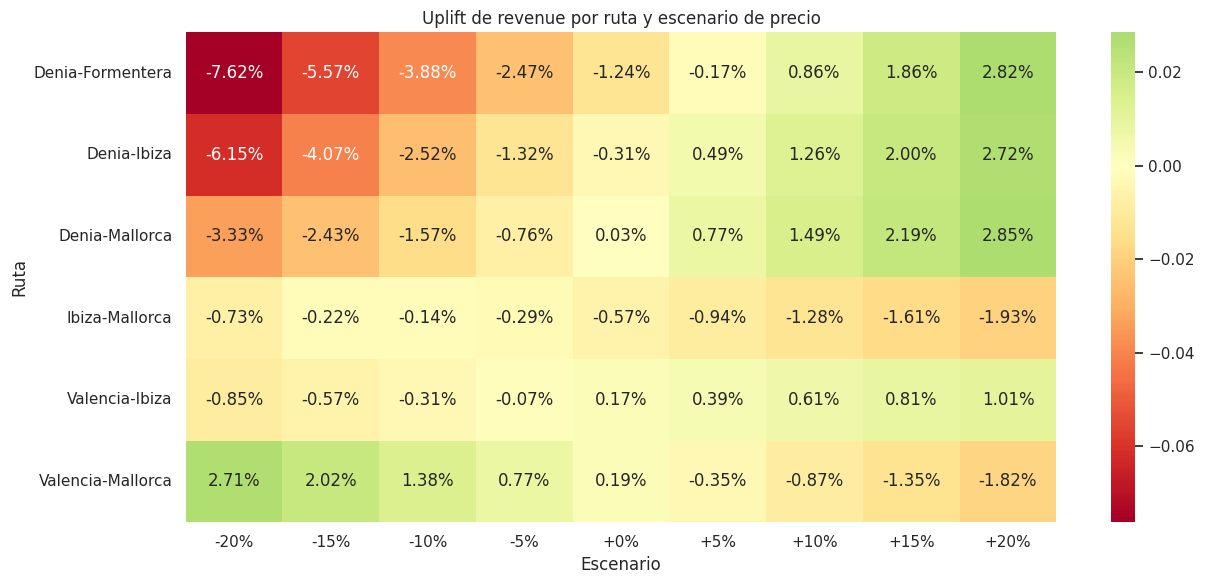

In [104]:
# ============================================================
# 22. HEATMAP: UPLIFT DE REVENUE POR RUTA Y ESCENARIO
# ============================================================

scenario_order = [f"{x:+.0%}" for x in price_scenarios]

revenue_uplift_pivot = route_scenario_summary.pivot(
    index="route",
    columns="scenario_label",
    values="revenue_uplift_pct"
)

revenue_uplift_pivot = revenue_uplift_pivot[scenario_order]

plt.figure(figsize=(13, 6))

sns.heatmap(
    revenue_uplift_pivot,
    annot=True,
    fmt=".2%",
    center=0,
    cmap="RdYlGn"
)

plt.title("Uplift de revenue por ruta y escenario de precio")
plt.xlabel("Escenario")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/36_heatmap_route_revenue_uplift_scenarios.png", dpi=300, bbox_inches="tight")

plt.show()

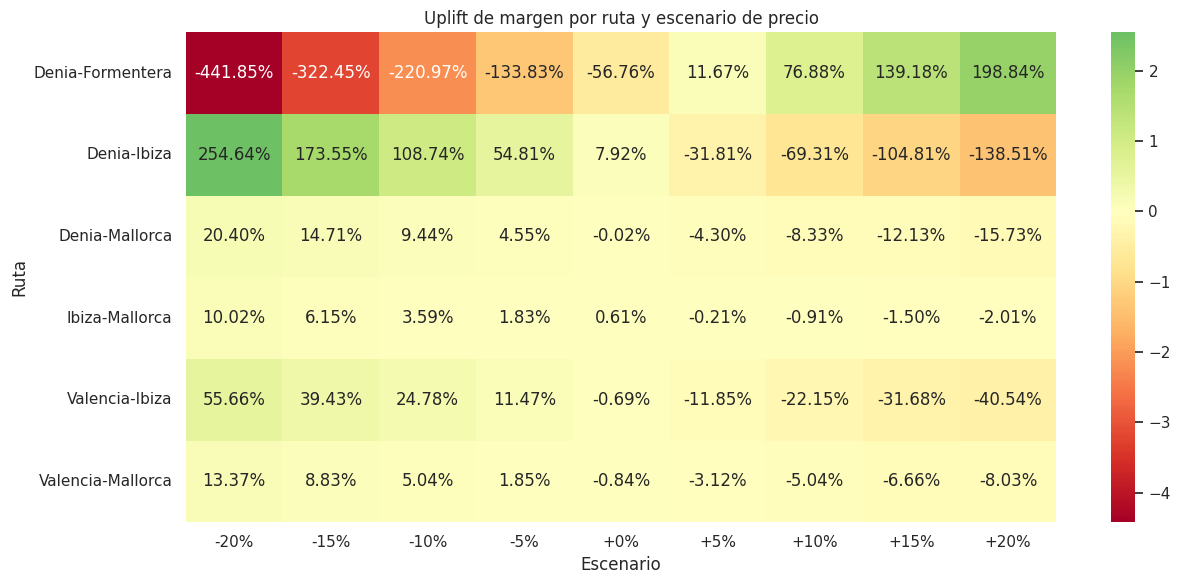

In [105]:
# ============================================================
# 23. HEATMAP: UPLIFT DE MARGEN POR RUTA Y ESCENARIO
# ============================================================

margin_uplift_pivot = route_scenario_summary.pivot(
    index="route",
    columns="scenario_label",
    values="margin_uplift_pct"
)

margin_uplift_pivot = margin_uplift_pivot[scenario_order]

plt.figure(figsize=(13, 6))

sns.heatmap(
    margin_uplift_pivot,
    annot=True,
    fmt=".2%",
    center=0,
    cmap="RdYlGn"
)

plt.title("Uplift de margen por ruta y escenario de precio")
plt.xlabel("Escenario")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/37_heatmap_route_margin_uplift_scenarios.png", dpi=300, bbox_inches="tight")

plt.show()

## 11. Mejor escenario por ruta

Identificamos para cada ruta:

- Escenario que maximiza revenue.
- Escenario que maximiza margen.
- Escenario equilibrado.

El escenario equilibrado busca mejorar margen y revenue evitando ocupaciones demasiado bajas o precios excesivamente premium.

In [106]:
# ============================================================
# 24. MEJOR ESCENARIO DE REVENUE Y MARGEN POR RUTA
# ============================================================

best_revenue_by_route = (
    route_scenario_summary
    .sort_values(["route", "simulated_revenue"], ascending=[True, False])
    .groupby("route")
    .head(1)
    .copy()
)

best_revenue_by_route["optimization_target"] = "Max revenue"

best_margin_by_route = (
    route_scenario_summary
    .sort_values(["route", "simulated_margin"], ascending=[True, False])
    .groupby("route")
    .head(1)
    .copy()
)

best_margin_by_route["optimization_target"] = "Max margin"

best_scenarios_by_route = pd.concat(
    [best_revenue_by_route, best_margin_by_route],
    ignore_index=True
)

best_scenarios_by_route = best_scenarios_by_route.sort_values(["route", "optimization_target"])

best_scenarios_by_route

,route,scenario_label,scenario_type,price_change_pct,trips,current_tickets,simulated_tickets,current_revenue,simulated_revenue,current_margin,simulated_margin,avg_current_occupancy,avg_simulated_occupancy,avg_current_price,avg_simulated_price,avg_simulated_margin_pct,avg_elasticity,revenue_uplift,revenue_uplift_pct,margin_uplift,margin_uplift_pct,tickets_change,tickets_change_pct,business_label,optimization_target
6,Denia-Formentera,+20%,Increase,0.2000,730,"137,510.8291","119,308.6115","10,829,083.5200","11,134,743.3452","222,050.5200","663,583.0644",0.6728,0.5837,76.6983,92.0379,-0.0524,-0.7788,"305,659.8252",0.0282,"441,532.5444",1.9884,"-18,202.2175",-0.1324,Neutral impact,Max margin
0,Denia-Formentera,+20%,Increase,0.2000,730,"137,510.8291","119,308.6115","10,829,083.5200","11,134,743.3452","222,050.5200","663,583.0644",0.6728,0.5837,76.6983,92.0379,-0.0524,-0.7788,"305,659.8252",0.0282,"441,532.5444",1.9884,"-18,202.2175",-0.1324,Neutral impact,Max revenue
7,Denia-Ibiza,+20%,Increase,0.2000,1095,"277,542.5490","238,311.0742","17,529,547.3700","18,006,121.2980","-576,840.6300","222,132.7047",0.7242,0.6218,62.0796,74.4955,-0.0784,-0.8359,"476,573.9280",0.0272,"798,973.3347",-1.3851,"-39,231.4748",-0.1414,Negative impact,Max margin
1,Denia-Ibiza,+20%,Increase,0.2000,1095,"277,542.5490","238,311.0742","17,529,547.3700","18,006,121.2980","-576,840.6300","222,132.7047",0.7242,0.6218,62.0796,74.4955,-0.0784,-0.8359,"476,573.9280",0.0272,"798,973.3347",-1.3851,"-39,231.4748",-0.1414,Negative impact,Max revenue
8,Denia-Mallorca,+20%,Increase,0.2000,730,"202,708.3062","173,696.6191","14,072,473.8100","14,473,864.2414","-4,376,746.1900","-3,688,101.9492",0.5340,0.4576,68.5058,82.2069,-0.3610,-0.8472,"401,390.4314",0.0285,"688,644.2408",-0.1573,"-29,011.6871",-0.1431,Negative impact,Max margin
2,Denia-Mallorca,+20%,Increase,0.2000,730,"202,708.3062","173,696.6191","14,072,473.8100","14,473,864.2414","-4,376,746.1900","-3,688,101.9492",0.5340,0.4576,68.5058,82.2069,-0.3610,-0.8472,"401,390.4314",0.0285,"688,644.2408",-0.1573,"-29,011.6871",-0.1431,Negative impact,Max revenue
9,Ibiza-Mallorca,+20%,Increase,0.2000,1095,"194,483.2227","159,861.8258","10,510,459.1000","10,307,942.5760","-3,808,748.9000","-3,732,090.2048",0.5920,0.4866,52.3318,62.7982,-0.6057,-1.0752,"-202,516.5240",-0.0193,"76,658.6952",-0.0201,"-34,621.3969",-0.1780,Neutral impact,Max margin
3,Ibiza-Mallorca,-10%,Discount,-0.1000,1095,"194,483.2227","217,162.1946","10,510,459.1000","10,495,841.7796","-3,808,748.9000","-3,945,293.5826",0.5920,0.6611,52.3318,47.0986,-0.6133,-1.0752,"-14,617.3204",-0.0014,"-136,544.6826",0.0359,"22,678.9719",0.1166,Margin improvement but revenue risk,Max revenue
10,Valencia-Ibiza,+20%,Increase,0.2000,730,"267,186.2705","224,525.7259","19,932,754.2000","20,134,410.4269","-1,598,389.8000","-950,372.5585",0.5903,0.4961,74.1938,89.0326,-0.1112,-0.9541,"201,656.2269",0.0101,"648,017.2415",-0.4054,"-42,660.5446",-0.1597,Negative impact,Max margin
4,Valencia-Ibiza,+20%,Increase,0.2000,730,"267,186.2705","224,525.7259","19,932,754.2000","20,134,410.4269","-1,598,389.8000","-950,372.5585",0.5903,0.4961,74.1938,89.0326,-0.1112,-0.9541,"201,656.2269",0.0101,"648,017.2415",-0.4054,"-42,660.5446",-0.1597,Negative impact,Max revenue


In [107]:
# ============================================================
# 25. ESCENARIO EQUILIBRADO POR RUTA
# ============================================================

balanced_candidates = route_scenario_summary[
    (route_scenario_summary["avg_simulated_occupancy"] >= 0.60) &
    (route_scenario_summary["avg_simulated_occupancy"] <= 0.92) &
    (route_scenario_summary["avg_simulated_margin_pct"] >= 0.20)
].copy()

if len(balanced_candidates) == 0:
    balanced_candidates = route_scenario_summary.copy()

balanced_candidates["balanced_score"] = (
    balanced_candidates["revenue_uplift_pct"] * 0.45 +
    balanced_candidates["margin_uplift_pct"] * 0.45 -
    np.abs(balanced_candidates["avg_simulated_occupancy"] - 0.80) * 0.10
)

best_balanced_by_route = (
    balanced_candidates
    .sort_values(["route", "balanced_score"], ascending=[True, False])
    .groupby("route")
    .head(1)
    .copy()
)

best_balanced_by_route["optimization_target"] = "Balanced recommendation"

best_balanced_by_route

,route,scenario_label,scenario_type,price_change_pct,trips,current_tickets,simulated_tickets,current_revenue,simulated_revenue,current_margin,simulated_margin,avg_current_occupancy,avg_simulated_occupancy,avg_current_price,avg_simulated_price,avg_simulated_margin_pct,avg_elasticity,revenue_uplift,revenue_uplift_pct,margin_uplift,margin_uplift_pct,tickets_change,tickets_change_pct,business_label,balanced_score,optimization_target
3,Denia-Formentera,+20%,Increase,0.2000,730,"137,510.8291","119,308.6115","10,829,083.5200","11,134,743.3452","222,050.5200","663,583.0644",0.6728,0.5837,76.6983,92.0379,-0.0524,-0.7788,"305,659.8252",0.0282,"441,532.5444",1.9884,"-18,202.2175",-0.1324,Neutral impact,0.8859,Balanced recommendation
16,Denia-Ibiza,-20%,Discount,-0.2000,1095,"277,542.5490","327,417.3646","17,529,547.3700","16,451,149.3787","-576,840.6300","-2,045,689.5384",0.7242,0.8543,62.0796,49.6636,-0.2126,-0.8359,"-1,078,397.9913",-0.0615,"-1,468,848.9084",2.5464,"49,874.8157",0.1797,Margin improvement but revenue risk,1.1128,Balanced recommendation
25,Denia-Mallorca,-20%,Discount,-0.2000,730,"202,708.3062","244,889.9989","14,072,473.8100","13,604,197.2396","-4,376,746.1900","-5,269,702.7496",0.5340,0.6451,68.5058,54.8046,-0.5027,-0.8472,"-468,276.5704",-0.0333,"-892,956.5596",0.2040,"42,181.6927",0.2081,Margin improvement but revenue risk,0.0613,Balanced recommendation
34,Ibiza-Mallorca,-20%,Discount,-0.2000,1095,"194,483.2227","243,395.4686","10,510,459.1000","10,434,247.0093","-3,808,748.9000","-4,190,521.2708",0.5920,0.7409,52.3318,41.8655,-0.6264,-1.0752,"-76,212.0907",-0.0073,"-381,772.3708",0.1002,"48,912.2459",0.2515,Margin improvement but revenue risk,0.0359,Balanced recommendation
43,Valencia-Ibiza,-20%,Discount,-0.2000,730,"267,186.2705","330,580.6676","19,932,754.2000","19,763,278.9824","-1,598,389.8000","-2,488,108.3614",0.5903,0.7304,74.1938,59.3551,-0.1934,-0.9541,"-169,475.2176",-0.0085,"-889,718.5614",0.5566,"63,394.3971",0.2373,Margin improvement but revenue risk,0.2397,Balanced recommendation
52,Valencia-Mallorca,-20%,Discount,-0.2000,1095,"451,884.5996","579,061.7957","30,124,521.7700","30,941,651.3207","-5,398,010.2300","-6,119,590.2276",0.5895,0.7555,66.2569,53.0055,-0.2671,-1.1114,"817,129.5507",0.0271,"-721,579.9976",0.1337,"127,177.1961",0.2814,Neutral impact,0.0679,Balanced recommendation


## 12. Recomendación inicial por ruta

Creamos una tabla ejecutiva que resume:

- Escenario recomendado.
- Cambio de precio sugerido.
- Uplift esperado en revenue.
- Uplift esperado en margen.
- Ocupación simulada.
- Elasticidad.
- Justificación.

In [108]:
# ============================================================
# 26. TABLA DE RECOMENDACIÓN INICIAL POR RUTA
# ============================================================

route_recommendation = best_balanced_by_route[[
    "route",
    "scenario_label",
    "price_change_pct",
    "avg_elasticity",
    "avg_current_price",
    "avg_simulated_price",
    "avg_current_occupancy",
    "avg_simulated_occupancy",
    "current_revenue",
    "simulated_revenue",
    "revenue_uplift",
    "revenue_uplift_pct",
    "current_margin",
    "simulated_margin",
    "margin_uplift",
    "margin_uplift_pct",
    "avg_simulated_margin_pct",
    "business_label"
]].copy()

def route_recommendation_text(row):
    if row["price_change_pct"] > 0:
        return "Controlled price increase"
    elif row["price_change_pct"] < 0:
        return "Promotional price adjustment"
    else:
        return "Maintain current price"

def route_recommendation_reason(row):
    if row["price_change_pct"] > 0:
        return "Scenario improves expected financial performance while preserving acceptable occupancy."
    elif row["price_change_pct"] < 0:
        return "Scenario seeks to recover demand and protect revenue through a controlled discount."
    else:
        return "Current pricing is close to the best balanced scenario."

route_recommendation["pricing_recommendation"] = route_recommendation.apply(route_recommendation_text, axis=1)
route_recommendation["recommendation_reason"] = route_recommendation.apply(route_recommendation_reason, axis=1)

route_recommendation = route_recommendation.sort_values("revenue_uplift_pct", ascending=False)

route_recommendation

,route,scenario_label,price_change_pct,avg_elasticity,avg_current_price,avg_simulated_price,avg_current_occupancy,avg_simulated_occupancy,current_revenue,simulated_revenue,revenue_uplift,revenue_uplift_pct,current_margin,simulated_margin,margin_uplift,margin_uplift_pct,avg_simulated_margin_pct,business_label,pricing_recommendation,recommendation_reason
3,Denia-Formentera,+20%,0.2000,-0.7788,76.6983,92.0379,0.6728,0.5837,"10,829,083.5200","11,134,743.3452","305,659.8252",0.0282,"222,050.5200","663,583.0644","441,532.5444",1.9884,-0.0524,Neutral impact,Controlled price increase,Scenario improves expected financial performan...
52,Valencia-Mallorca,-20%,-0.2000,-1.1114,66.2569,53.0055,0.5895,0.7555,"30,124,521.7700","30,941,651.3207","817,129.5507",0.0271,"-5,398,010.2300","-6,119,590.2276","-721,579.9976",0.1337,-0.2671,Neutral impact,Promotional price adjustment,Scenario seeks to recover demand and protect r...
34,Ibiza-Mallorca,-20%,-0.2000,-1.0752,52.3318,41.8655,0.5920,0.7409,"10,510,459.1000","10,434,247.0093","-76,212.0907",-0.0073,"-3,808,748.9000","-4,190,521.2708","-381,772.3708",0.1002,-0.6264,Margin improvement but revenue risk,Promotional price adjustment,Scenario seeks to recover demand and protect r...
43,Valencia-Ibiza,-20%,-0.2000,-0.9541,74.1938,59.3551,0.5903,0.7304,"19,932,754.2000","19,763,278.9824","-169,475.2176",-0.0085,"-1,598,389.8000","-2,488,108.3614","-889,718.5614",0.5566,-0.1934,Margin improvement but revenue risk,Promotional price adjustment,Scenario seeks to recover demand and protect r...
25,Denia-Mallorca,-20%,-0.2000,-0.8472,68.5058,54.8046,0.5340,0.6451,"14,072,473.8100","13,604,197.2396","-468,276.5704",-0.0333,"-4,376,746.1900","-5,269,702.7496","-892,956.5596",0.2040,-0.5027,Margin improvement but revenue risk,Promotional price adjustment,Scenario seeks to recover demand and protect r...
16,Denia-Ibiza,-20%,-0.2000,-0.8359,62.0796,49.6636,0.7242,0.8543,"17,529,547.3700","16,451,149.3787","-1,078,397.9913",-0.0615,"-576,840.6300","-2,045,689.5384","-1,468,848.9084",2.5464,-0.2126,Margin improvement but revenue risk,Promotional price adjustment,Scenario seeks to recover demand and protect r...


## 13. Recomendación por viaje

Además del resumen por ruta, generamos una tabla a nivel de viaje con la mejor recomendación balanceada.

Esto es útil para un futuro dashboard o para crear alertas operativas.

In [109]:
# ============================================================
# 27. MEJOR ESCENARIO BALANCEADO POR VIAJE
# ============================================================

trip_candidates = simulation_detail[
    (simulation_detail["simulated_occupancy_rate"] >= 0.55) &
    (simulation_detail["simulated_margin_pct"] >= 0.15)
].copy()

if len(trip_candidates) == 0:
    trip_candidates = simulation_detail.copy()

trip_candidates["trip_balanced_score"] = (
    trip_candidates["revenue_uplift_pct"] * 0.40 +
    trip_candidates["margin_uplift_pct"] * 0.40 -
    np.abs(trip_candidates["simulated_occupancy_rate"] - 0.80) * 0.20
)

best_trip_recommendation = (
    trip_candidates
    .sort_values(["trip_id", "trip_balanced_score"], ascending=[True, False])
    .groupby("trip_id")
    .head(1)
    .copy()
)

best_trip_recommendation = best_trip_recommendation[[
    "trip_id",
    "trip_date",
    "departure_datetime",
    "route",
    "season",
    "day_of_week",
    "departure_hour",
    "booking_window",
    "capacity",
    "avg_ticket_price",
    "simulated_ticket_price",
    "price_change_pct",
    "scenario_label",
    "base_demand_for_simulation",
    "simulated_tickets_sold",
    "base_occupancy_for_simulation",
    "simulated_occupancy_rate",
    "revenue",
    "simulated_revenue",
    "revenue_uplift",
    "revenue_uplift_pct",
    "margin",
    "simulated_margin",
    "margin_uplift",
    "margin_uplift_pct",
    "simulated_margin_pct",
    "elasticity_for_simulation",
    "occupancy_risk",
    "margin_health",
    "price_position",
    "pricing_action",
    "trip_balanced_score"
]].sort_values(["route", "trip_date", "departure_hour"])

best_trip_recommendation.head()

,trip_id,trip_date,departure_datetime,route,season,day_of_week,departure_hour,booking_window,capacity,avg_ticket_price,simulated_ticket_price,price_change_pct,scenario_label,base_demand_for_simulation,simulated_tickets_sold,base_occupancy_for_simulation,simulated_occupancy_rate,revenue,simulated_revenue,revenue_uplift,revenue_uplift_pct,margin,simulated_margin,margin_uplift,margin_uplift_pct,simulated_margin_pct,elasticity_for_simulation,occupancy_risk,margin_health,price_position,pricing_action,trip_balanced_score
45153,TRIP_001354,2025-04-01,2025-04-01 09:00:00,Denia-Formentera,Shoulder,Tuesday,9,Medium,280,75.3800,90.4560,0.2000,+20%,220.4407,191.2611,0.7873,0.6831,"15,905.1800","17,300.7129","1,395.5329",0.0877,"1,228.1800","2,761.8853","1,533.7053",1.2488,0.1596,-0.7788,Healthy occupancy,Weak margin,Premium vs competitor,Manual review,0.5112
45184,TRIP_001385,2025-04-03,2025-04-03 17:00:00,Denia-Formentera,Shoulder,Thursday,17,Early,280,69.8600,83.8320,0.2000,+20%,259.3008,224.9773,0.9261,0.8035,"19,001.9200","18,860.2968",-141.6232,-0.0075,"3,897.9200","4,085.4557",187.5357,0.0481,0.2166,-0.7788,Healthy occupancy,Weak margin,Premium vs competitor,Maintain / monitor,0.0156
6873,TRIP_001399,2025-04-04,2025-04-04 09:00:00,Denia-Formentera,Shoulder,Friday,9,Medium,280,78.6100,66.8185,-0.1500,-15%,255.7828,280.0000,0.9135,1.0000,"13,835.3600","18,709.1800","4,873.8200",0.3523,-596.6400,"3,549.1800","4,145.8200",-6.9486,0.1897,-0.7788,Saturation risk,Weak margin,Discounted vs competitor,Manual review,-2.6785
45213,TRIP_001414,2025-04-05,2025-04-05 09:00:00,Denia-Formentera,Shoulder,Saturday,9,Medium,280,73.3100,87.9720,0.2000,+20%,280.0000,242.9366,1.0000,0.8676,"19,573.7700","21,371.6173","1,797.8473",0.0918,"4,504.7700","6,471.0612","1,966.2912",0.4365,0.3028,-0.7788,High occupancy,Healthy margin,Premium vs competitor,Maintain / monitor,0.1978
45228,TRIP_001429,2025-04-06,2025-04-06 09:00:00,Denia-Formentera,Shoulder,Sunday,9,Medium,280,77.6000,93.1200,0.2000,+20%,242.9586,210.7983,0.8677,0.7529,"17,925.6000","19,629.5413","1,703.9413",0.0951,"3,108.6000","4,953.9529","1,845.3529",0.5936,0.2524,-0.7788,Healthy occupancy,Healthy margin,Premium vs competitor,Maintain / monitor,0.2660


## 14. Distribución de acciones recomendadas

Analizamos qué tipo de acción aparece con más frecuencia.

In [110]:
# ============================================================
# 28. DISTRIBUCIÓN DE ACCIONES RECOMENDADAS
# ============================================================

action_distribution = (
    best_trip_recommendation["pricing_action"]
    .value_counts()
    .reset_index()
)

action_distribution.columns = ["pricing_action", "number_of_trips"]

action_distribution

,pricing_action,number_of_trips
0,Maintain / monitor,446
1,Manual review,434
2,Candidate for controlled increase,9
3,Candidate for promotion,3


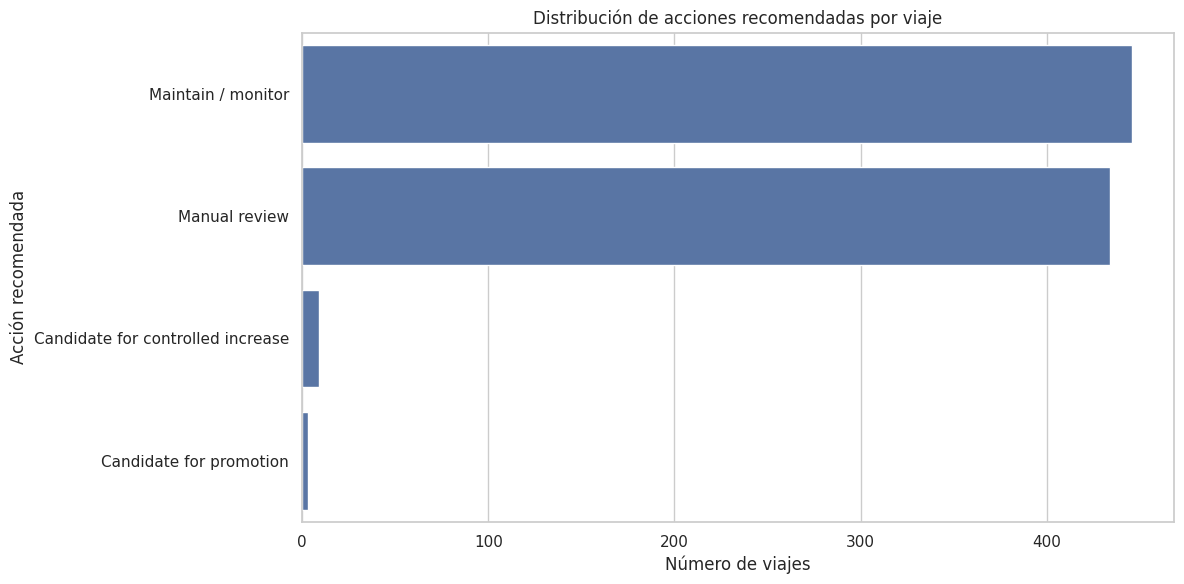

In [111]:
# ============================================================
# 29. GRÁFICO: ACCIONES RECOMENDADAS
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=action_distribution,
    x="number_of_trips",
    y="pricing_action"
)

plt.title("Distribución de acciones recomendadas por viaje")
plt.xlabel("Número de viajes")
plt.ylabel("Acción recomendada")
plt.tight_layout()

plt.savefig(f"{images_path}/38_recommended_pricing_actions_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## 15. Riesgo de ocupación por ruta

Identificamos si las recomendaciones generan riesgo de baja ocupación o saturación.

In [112]:
# ============================================================
# 30. RIESGO DE OCUPACIÓN POR RUTA
# ============================================================

occupancy_risk_route = pd.crosstab(
    best_trip_recommendation["route"],
    best_trip_recommendation["occupancy_risk"],
    normalize="index"
).reset_index()

occupancy_risk_route

occupancy_risk,route,Healthy occupancy,High occupancy,Saturation risk,Soft demand
0,Denia-Formentera,0.7277,0.0553,0.0170,0.2000
1,Denia-Ibiza,0.7762,0.1119,0.0108,0.1011
2,Denia-Mallorca,0.0638,0.0000,0.0000,0.9362
3,Ibiza-Mallorca,0.7670,0.0291,0.1553,0.0485
4,Valencia-Ibiza,0.1240,0.0000,0.0000,0.8760
5,Valencia-Mallorca,0.8716,0.0092,0.0000,0.1193


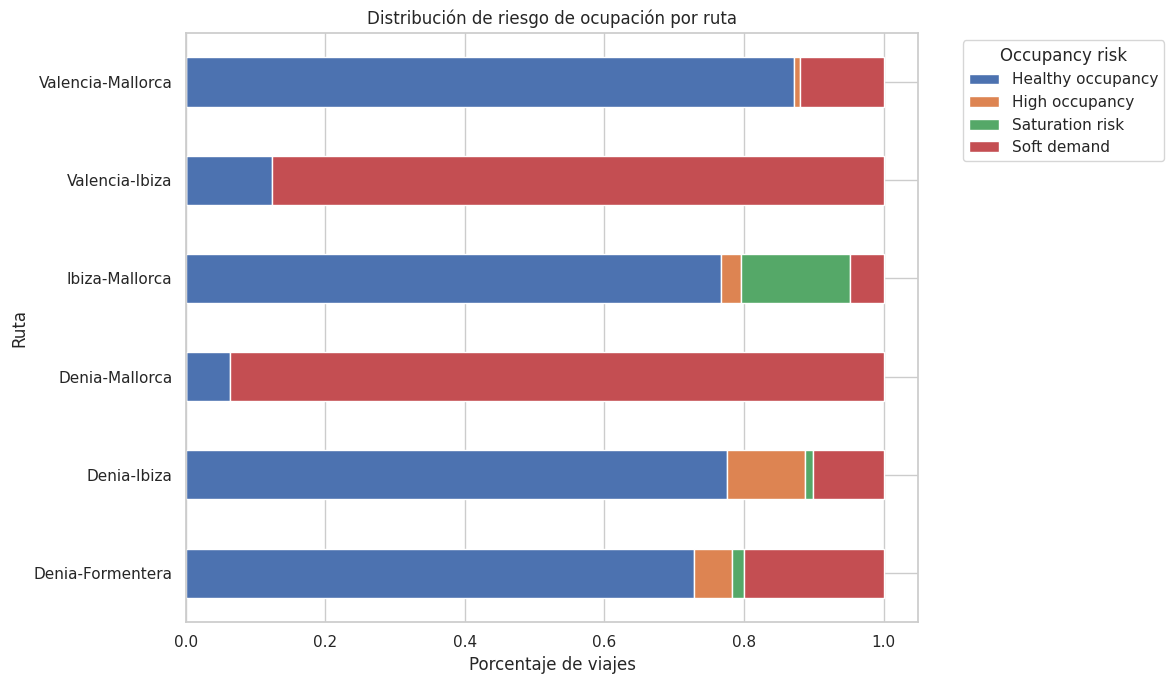

In [113]:
# ============================================================
# 31. GRÁFICO: RIESGO DE OCUPACIÓN POR RUTA
# ============================================================

occupancy_risk_plot = pd.crosstab(
    best_trip_recommendation["route"],
    best_trip_recommendation["occupancy_risk"],
    normalize="index"
)

occupancy_risk_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Distribución de riesgo de ocupación por ruta")
plt.xlabel("Porcentaje de viajes")
plt.ylabel("Ruta")
plt.legend(title="Occupancy risk", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(f"{images_path}/39_occupancy_risk_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

## 16. Simulador interactivo en Colab

Además de las tablas y gráficos estáticos, añadimos un simulador interactivo para probar escenarios manualmente.

El simulador permite modificar:

- Ruta.
- Cambio de precio.
- Demanda externa.
- Shock de coste.

Con esos parámetros calcula:

- Precio simulado.
- Demanda estimada.
- Ocupación esperada.
- Revenue.
- Margen.
- Variación frente al escenario actual.

Este bloque es especialmente útil para explicar el proyecto en una entrevista o para enseñar el valor del análisis a una persona de negocio.

In [114]:
# ============================================================
# 32A. PREPARAR DATOS PARA SIMULADOR INTERACTIVO
# ============================================================

route_simulator_base = (
    simulation_base
    .groupby("route")
    .agg(
        avg_ticket_price=("avg_ticket_price", "mean"),
        avg_occupancy=("base_occupancy_for_simulation", "mean"),
        avg_capacity=("capacity", "mean"),
        avg_fixed_cost=("fixed_operational_cost", "mean"),
        avg_variable_cost=("variable_cost_per_passenger", "mean"),
        avg_elasticity=("elasticity_for_simulation", "mean"),
        avg_competitor_price=("competitor_price", "mean"),
        current_revenue=("revenue", "sum"),
        current_margin=("margin", "sum"),
        trips=("trip_id", "count")
    )
    .reset_index()
)

route_simulator_base["current_tickets_per_trip"] = (
    route_simulator_base["avg_capacity"] * route_simulator_base["avg_occupancy"]
)

route_simulator_base["current_revenue_per_trip"] = (
    route_simulator_base["current_revenue"] / route_simulator_base["trips"]
)

route_simulator_base["current_margin_per_trip"] = (
    route_simulator_base["current_margin"] / route_simulator_base["trips"]
)

route_simulator_base

,route,avg_ticket_price,avg_occupancy,avg_capacity,avg_fixed_cost,avg_variable_cost,avg_elasticity,avg_competitor_price,current_revenue,current_margin,trips,current_tickets_per_trip,current_revenue_per_trip,current_margin_per_trip
0,Denia-Formentera,76.6983,0.6728,280.0000,"13,200.0000",7.0000,-0.7788,75.2875,"10,829,083.5200","222,050.5200",730,188.3710,"14,834.3610",304.1788
1,Denia-Ibiza,62.0796,0.7242,350.0000,"14,500.0000",8.0000,-0.8359,60.8638,"17,529,547.3700","-576,840.6300",1095,253.4635,"16,008.7191",-526.7951
2,Denia-Mallorca,68.5058,0.5340,520.0000,"22,500.0000",10.0000,-0.8472,67.1667,"14,072,473.8100","-4,376,746.1900",730,277.6826,"19,277.3614","-5,995.5427"
3,Ibiza-Mallorca,52.3318,0.5920,300.0000,"11,800.0000",7.0000,-1.0752,51.3974,"10,510,459.1000","-3,808,748.9000",1095,177.6102,"9,598.5928","-3,478.3095"
4,Valencia-Ibiza,74.1938,0.5903,620.0000,"25,500.0000",11.0000,-0.9541,72.9986,"19,932,754.2000","-1,598,389.8000",730,366.0086,"27,305.1427","-2,189.5751"
5,Valencia-Mallorca,66.2569,0.5895,700.0000,"27,500.0000",12.0000,-1.1114,65.0386,"30,124,521.7700","-5,398,010.2300",1095,412.6800,"27,510.9788","-4,929.6897"


In [115]:
# ============================================================
# 32B. SIMULADOR INTERACTIVO EN COLAB
# ============================================================

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

    route_dropdown = widgets.Dropdown(
        options=sorted(route_simulator_base["route"].unique()),
        description="Ruta:",
        layout=widgets.Layout(width="420px")
    )

    price_slider = widgets.IntSlider(
        value=0,
        min=-20,
        max=25,
        step=1,
        description="Precio:",
        continuous_update=False,
        layout=widgets.Layout(width="520px")
    )

    demand_slider = widgets.IntSlider(
        value=100,
        min=75,
        max=130,
        step=1,
        description="Demanda:",
        continuous_update=False,
        layout=widgets.Layout(width="520px")
    )

    cost_slider = widgets.IntSlider(
        value=0,
        min=-10,
        max=25,
        step=1,
        description="Coste:",
        continuous_update=False,
        layout=widgets.Layout(width="520px")
    )

    simulator_output = widgets.Output()

    def format_eur(value):
        return f"{value:,.0f} €".replace(",", "X").replace(".", ",").replace("X", ".")

    def format_pct(value):
        return f"{value:.1%}".replace(".", ",")

    def update_interactive_simulator(*args):
        with simulator_output:
            clear_output(wait=True)

            route = route_dropdown.value
            price_change = price_slider.value / 100
            external_demand_factor = demand_slider.value / 100
            cost_shock = cost_slider.value / 100

            row = route_simulator_base[route_simulator_base["route"] == route].iloc[0]

            current_price = row["avg_ticket_price"]
            simulated_price = current_price * (1 + price_change)

            current_tickets = row["current_tickets_per_trip"]
            capacity = row["avg_capacity"]
            elasticity = row["avg_elasticity"]

            simulated_demand = (
                current_tickets *
                external_demand_factor *
                ((simulated_price / current_price) ** elasticity)
            )

            simulated_tickets = min(max(simulated_demand, 0), capacity)
            simulated_occupancy = simulated_tickets / capacity

            current_revenue = row["current_revenue_per_trip"]
            current_margin = row["current_margin_per_trip"]

            simulated_revenue = simulated_tickets * simulated_price

            simulated_cost = (
                row["avg_fixed_cost"] +
                simulated_tickets * row["avg_variable_cost"]
            ) * (1 + cost_shock)

            simulated_margin = simulated_revenue - simulated_cost

            revenue_delta_pct = (
                (simulated_revenue / current_revenue) - 1
                if current_revenue != 0 else 0
            )

            margin_delta_pct = (
                (simulated_margin / current_margin) - 1
                if current_margin != 0 else 0
            )

            price_index = simulated_price / row["avg_competitor_price"]

            if simulated_occupancy >= 0.95:
                occupancy_label = "Riesgo de saturación"
            elif simulated_occupancy >= 0.85:
                occupancy_label = "Ocupación alta"
            elif simulated_occupancy >= 0.65:
                occupancy_label = "Ocupación saludable"
            elif simulated_occupancy >= 0.50:
                occupancy_label = "Demanda suave"
            else:
                occupancy_label = "Riesgo de baja ocupación"

            if simulated_margin > current_margin and simulated_revenue > current_revenue:
                recommendation = "Escenario atractivo: mejora revenue y margen."
            elif simulated_revenue > current_revenue and simulated_margin <= current_margin:
                recommendation = "Mejora revenue, pero revisar impacto en margen."
            elif simulated_margin > current_margin and simulated_revenue <= current_revenue:
                recommendation = "Mejora margen, pero revisar impacto comercial."
            else:
                recommendation = "Escenario débil: mantener o revisar manualmente."

            cards_html = f'''
            <div style="font-family:Arial; margin-top:10px;">
                <h3 style="margin-bottom:8px;">Simulador de pricing — {route}</h3>
                <div style="display:grid; grid-template-columns: repeat(4, 1fr); gap:10px;">
                    <div style="border:1px solid #ddd; border-radius:10px; padding:12px;">
                        <div style="color:#666;">Precio simulado</div>
                        <div style="font-size:22px; font-weight:bold;">{format_eur(simulated_price)}</div>
                        <div style="font-size:12px;">Base: {format_eur(current_price)} · Cambio: {price_slider.value:+d}%</div>
                    </div>
                    <div style="border:1px solid #ddd; border-radius:10px; padding:12px;">
                        <div style="color:#666;">Ocupación esperada</div>
                        <div style="font-size:22px; font-weight:bold;">{format_pct(simulated_occupancy)}</div>
                        <div style="font-size:12px;">{simulated_tickets:,.0f} de {capacity:,.0f} plazas</div>
                    </div>
                    <div style="border:1px solid #ddd; border-radius:10px; padding:12px;">
                        <div style="color:#666;">Revenue por viaje</div>
                        <div style="font-size:22px; font-weight:bold;">{format_eur(simulated_revenue)}</div>
                        <div style="font-size:12px;">{format_pct(revenue_delta_pct)} vs actual</div>
                    </div>
                    <div style="border:1px solid #ddd; border-radius:10px; padding:12px;">
                        <div style="color:#666;">Margen por viaje</div>
                        <div style="font-size:22px; font-weight:bold;">{format_eur(simulated_margin)}</div>
                        <div style="font-size:12px;">{format_pct(margin_delta_pct)} vs actual</div>
                    </div>
                </div>
                <p style="margin-top:12px;"><b>Diagnóstico:</b> {occupancy_label}. Índice frente al competidor: {price_index:.2f}. Elasticidad: {elasticity:.2f}.</p>
                <p><b>Lectura:</b> {recommendation}</p>
            </div>
            '''

            display(HTML(cards_html))

            comparison = pd.DataFrame({
                "metric": ["Revenue", "Margen"],
                "Actual": [current_revenue, current_margin],
                "Simulado": [simulated_revenue, simulated_margin]
            })

            comparison_plot = comparison.melt(
                id_vars="metric",
                value_vars=["Actual", "Simulado"],
                var_name="Escenario",
                value_name="Valor"
            )

            plt.figure(figsize=(9, 4))
            sns.barplot(
                data=comparison_plot,
                x="metric",
                y="Valor",
                hue="Escenario"
            )
            plt.title("Comparación actual vs escenario simulado")
            plt.xlabel("")
            plt.ylabel("€ por viaje")
            plt.tight_layout()
            plt.show()

    for widget in [route_dropdown, price_slider, demand_slider, cost_slider]:
        widget.observe(update_interactive_simulator, names="value")

    display(
        widgets.VBox([
            widgets.HTML("<h3>Controles del simulador</h3>"),
            route_dropdown,
            price_slider,
            demand_slider,
            cost_slider,
            simulator_output
        ])
    )

    update_interactive_simulator()

except Exception as e:
    print("No se pudo cargar ipywidgets en este entorno.")
    print("Error:", e)

## 17. Exportación de simulador HTML interactivo

Además del simulador dentro de Colab, generamos un archivo HTML autónomo.

Este archivo podrá abrirse directamente en el navegador y quedará guardado en:

`dashboard/pricing_interactive_simulator.html`

El HTML incluye:

- Selector de ruta.
- Slider de cambio de precio.
- Slider de demanda externa.
- Slider de shock de coste.
- KPIs dinámicos.
- Comparación visual entre escenario actual y simulado.

In [116]:
# ============================================================
# 32C. CREACIÓN DE SIMULADOR HTML AUTÓNOMO
# ============================================================

import json

dashboard_path = f"{base_path}/dashboard"
os.makedirs(dashboard_path, exist_ok=True)

simulator_data = {}

for _, row in route_simulator_base.iterrows():
    simulator_data[row["route"]] = {
        "price": float(row["avg_ticket_price"]),
        "occupancy": float(row["avg_occupancy"]),
        "capacity": float(row["avg_capacity"]),
        "fixed": float(row["avg_fixed_cost"]),
        "variable": float(row["avg_variable_cost"]),
        "elasticity": float(row["avg_elasticity"]),
        "competitor": float(row["avg_competitor_price"]),
        "currentRevenue": float(row["current_revenue_per_trip"]),
        "currentMargin": float(row["current_margin_per_trip"])
    }

simulator_json = json.dumps(simulator_data, ensure_ascii=False)

html_template = f'''
<!doctype html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Levante Ferries — Pricing Simulator</title>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 0;
        padding: 24px;
        background: #f6f8fb;
        color: #1f2937;
    }}
    .container {{
        max-width: 1100px;
        margin: 0 auto;
    }}
    .header {{
        margin-bottom: 18px;
    }}
    .header h1 {{
        margin: 0 0 6px 0;
        font-size: 28px;
    }}
    .header p {{
        margin: 0;
        color: #6b7280;
    }}
    .panel {{
        background: white;
        border: 1px solid #e5e7eb;
        border-radius: 16px;
        padding: 18px;
        margin-bottom: 16px;
        box-shadow: 0 8px 22px rgba(15, 23, 42, 0.04);
    }}
    .controls {{
        display: grid;
        grid-template-columns: repeat(4, minmax(180px, 1fr));
        gap: 14px;
    }}
    label {{
        display: block;
        font-weight: 700;
        font-size: 13px;
        margin-bottom: 6px;
    }}
    select, input[type="range"] {{
        width: 100%;
    }}
    select {{
        padding: 9px;
        border-radius: 10px;
        border: 1px solid #d1d5db;
        background: white;
    }}
    .value {{
        font-weight: 400;
        color: #2563eb;
    }}
    .kpis {{
        display: grid;
        grid-template-columns: repeat(4, 1fr);
        gap: 14px;
    }}
    .card {{
        background: white;
        border: 1px solid #e5e7eb;
        border-radius: 16px;
        padding: 16px;
        box-shadow: 0 8px 22px rgba(15, 23, 42, 0.04);
    }}
    .card .label {{
        color: #6b7280;
        font-size: 13px;
        margin-bottom: 6px;
    }}
    .card .number {{
        font-size: 26px;
        font-weight: 800;
        margin-bottom: 4px;
    }}
    .card .context {{
        color: #6b7280;
        font-size: 12px;
    }}
    .diagnosis {{
        font-size: 15px;
        line-height: 1.5;
    }}
    .good {{
        color: #047857;
        font-weight: 700;
    }}
    .warning {{
        color: #b45309;
        font-weight: 700;
    }}
    .bad {{
        color: #b91c1c;
        font-weight: 700;
    }}
    svg {{
        width: 100%;
        height: auto;
        overflow: visible;
    }}
    .grid {{
        stroke: #e5e7eb;
        stroke-width: 1;
    }}
    .current {{
        fill: #9ca3af;
        opacity: 0.55;
    }}
    .simulated {{
        fill: #2563eb;
    }}
    .axis, .small {{
        fill: #6b7280;
        font-size: 12px;
    }}
    .label-text {{
        fill: #111827;
        font-weight: 700;
    }}
    .value-text {{
        fill: #111827;
        font-size: 12px;
    }}
    @media (max-width: 850px) {{
        .controls, .kpis {{
            grid-template-columns: 1fr;
        }}
    }}
</style>
</head>
<body>
<div class="container">
    <div class="header">
        <h1>Levante Ferries — Pricing Simulator</h1>
        <p>Simulador interactivo de escenarios de precio, demanda externa y shock de coste.</p>
    </div>

    <div class="panel">
        <div class="controls">
            <div>
                <label for="route">Ruta</label>
                <select id="route"></select>
            </div>
            <div>
                <label for="price">Cambio de precio: <span class="value" id="priceValue">0%</span></label>
                <input id="price" type="range" min="-20" max="25" value="0" step="1">
            </div>
            <div>
                <label for="demand">Demanda externa: <span class="value" id="demandValue">100%</span></label>
                <input id="demand" type="range" min="75" max="130" value="100" step="1">
            </div>
            <div>
                <label for="cost">Shock de coste: <span class="value" id="costValue">0%</span></label>
                <input id="cost" type="range" min="-10" max="25" value="0" step="1">
            </div>
        </div>
    </div>

    <div class="kpis">
        <div class="card">
            <div class="label">Precio simulado</div>
            <div class="number" id="kPrice"></div>
            <div class="context" id="kPriceContext"></div>
        </div>
        <div class="card">
            <div class="label">Ocupación esperada</div>
            <div class="number" id="kOcc"></div>
            <div class="context" id="kTickets"></div>
        </div>
        <div class="card">
            <div class="label">Revenue por viaje</div>
            <div class="number" id="kRevenue"></div>
            <div class="context" id="kRevenueDelta"></div>
        </div>
        <div class="card">
            <div class="label">Margen por viaje</div>
            <div class="number" id="kMargin"></div>
            <div class="context" id="kMarginDelta"></div>
        </div>
    </div>

    <div class="panel">
        <svg id="chart" viewBox="0 0 900 270" role="img">
            <g id="chartContent"></g>
        </svg>
    </div>

    <div class="panel diagnosis" id="diagnosis"></div>
</div>

<script>
const routes = {simulator_json};

const euro = (v) => new Intl.NumberFormat("es-ES", {{
    style: "currency",
    currency: "EUR",
    maximumFractionDigits: 0
}}).format(v);

const pct = (v) => new Intl.NumberFormat("es-ES", {{
    style: "percent",
    maximumFractionDigits: 1,
    signDisplay: "exceptZero"
}}).format(v);

const q = (id) => document.getElementById(id);

function drawChart(values) {{
    const max = Math.max(...values.flatMap(d => [d.current, d.simulated]), 1);
    const x0 = 180;
    const width = 590;
    let html = "";

    [0, 0.25, 0.50, 0.75, 1].forEach(t => {{
        const x = x0 + width * t;
        html += `<line class="grid" x1="${{x}}" y1="25" x2="${{x}}" y2="220"></line>`;
        html += `<text class="axis" x="${{x}}" y="250" text-anchor="middle">${{euro(max * t)}}</text>`;
    }});

    values.forEach((d, i) => {{
        const y = 55 + i * 95;
        const cw = width * d.current / max;
        const sw = width * d.simulated / max;

        html += `<text class="label-text" x="10" y="${{y + 22}}">${{d.label}}</text>`;
        html += `<rect class="current" x="${{x0}}" y="${{y}}" width="${{cw}}" height="24" rx="5"></rect>`;
        html += `<rect class="simulated" x="${{x0}}" y="${{y + 34}}" width="${{sw}}" height="24" rx="5"></rect>`;
        html += `<text class="value-text" x="${{Math.min(x0 + cw + 8, 850)}}" y="${{y + 17}}">${{euro(d.current)}}</text>`;
        html += `<text class="value-text" x="${{Math.min(x0 + sw + 8, 850)}}" y="${{y + 51}}">${{euro(d.simulated)}}</text>`;
    }});

    q("chartContent").innerHTML = html;
}}

function update() {{
    const routeName = q("route").value;
    const r = routes[routeName];

    const priceDelta = Number(q("price").value) / 100;
    const demandFactor = Number(q("demand").value) / 100;
    const costShock = Number(q("cost").value) / 100;

    q("priceValue").textContent = pct(priceDelta);
    q("demandValue").textContent = pct(demandFactor);
    q("costValue").textContent = pct(costShock);

    const currentTickets = r.capacity * r.occupancy;
    const currentRevenue = r.currentRevenue;
    const currentMargin = r.currentMargin;

    const simulatedPrice = r.price * (1 + priceDelta);
    const simulatedDemand = currentTickets * demandFactor * Math.pow((simulatedPrice / r.price), r.elasticity);
    const simulatedTickets = Math.min(Math.max(simulatedDemand, 0), r.capacity);
    const simulatedOccupancy = simulatedTickets / r.capacity;
    const simulatedRevenue = simulatedTickets * simulatedPrice;

    const simulatedCost = (r.fixed + simulatedTickets * r.variable) * (1 + costShock);
    const simulatedMargin = simulatedRevenue - simulatedCost;

    const revenueDelta = currentRevenue !== 0 ? simulatedRevenue / currentRevenue - 1 : 0;
    const marginDelta = currentMargin !== 0 ? simulatedMargin / currentMargin - 1 : 0;
    const priceIndex = simulatedPrice / r.competitor;

    let risk = "Ocupación saludable";
    let riskClass = "good";

    if (simulatedOccupancy >= 0.95) {{
        risk = "Riesgo de saturación";
        riskClass = "warning";
    }} else if (simulatedOccupancy >= 0.85) {{
        risk = "Ocupación alta";
        riskClass = "good";
    }} else if (simulatedOccupancy < 0.50) {{
        risk = "Riesgo de baja ocupación";
        riskClass = "bad";
    }} else if (simulatedOccupancy < 0.65) {{
        risk = "Demanda suave";
        riskClass = "warning";
    }}

    let recommendation = "Mantener o revisar manualmente.";
    let recommendationClass = "warning";

    if (simulatedRevenue > currentRevenue && simulatedMargin > currentMargin) {{
        recommendation = "Escenario atractivo: mejora revenue y margen.";
        recommendationClass = "good";
    }} else if (simulatedRevenue > currentRevenue && simulatedMargin <= currentMargin) {{
        recommendation = "Mejora revenue, pero revisar impacto en margen.";
        recommendationClass = "warning";
    }} else if (simulatedRevenue <= currentRevenue && simulatedMargin > currentMargin) {{
        recommendation = "Mejora margen, pero revisar impacto comercial.";
        recommendationClass = "warning";
    }} else {{
        recommendation = "Escenario débil: no mejora las métricas principales.";
        recommendationClass = "bad";
    }}

    q("kPrice").textContent = euro(simulatedPrice);
    q("kPriceContext").textContent = `Base ${{euro(r.price)}} · elasticidad ${{r.elasticity.toFixed(2)}}`;

    q("kOcc").textContent = pct(simulatedOccupancy);
    q("kTickets").textContent = `${{Math.round(simulatedTickets).toLocaleString("es-ES")}} de ${{Math.round(r.capacity).toLocaleString("es-ES")}} plazas`;

    q("kRevenue").textContent = euro(simulatedRevenue);
    q("kRevenueDelta").textContent = `${{pct(revenueDelta)}} vs actual`;

    q("kMargin").textContent = euro(simulatedMargin);
    q("kMarginDelta").textContent = `${{pct(marginDelta)}} vs actual`;

    q("diagnosis").innerHTML = `
        <p><b>Ruta:</b> ${{routeName}}</p>
        <p><b>Diagnóstico de ocupación:</b> <span class="${{riskClass}}">${{risk}}</span></p>
        <p><b>Índice frente al competidor:</b> ${{priceIndex.toFixed(2)}} · <b>Elasticidad:</b> ${{r.elasticity.toFixed(2)}}</p>
        <p><b>Lectura ejecutiva:</b> <span class="${{recommendationClass}}">${{recommendation}}</span></p>
    `;

    drawChart([
        {{label: "Revenue", current: currentRevenue, simulated: simulatedRevenue}},
        {{label: "Margen", current: currentMargin, simulated: simulatedMargin}}
    ]);
}}

function initialize() {{
    const routeSelect = q("route");
    Object.keys(routes).sort().forEach(route => {{
        const option = document.createElement("option");
        option.value = route;
        option.textContent = route;
        routeSelect.appendChild(option);
    }});

    ["route", "price", "demand", "cost"].forEach(id => {{
        q(id).addEventListener("input", update);
    }});

    update();
}}

initialize();
</script>
</body>
</html>
'''

html_output_path = f"{dashboard_path}/pricing_interactive_simulator.html"

with open(html_output_path, "w", encoding="utf-8") as file:
    file.write(html_template)

print("Simulador HTML exportado correctamente en:")
print(html_output_path)

Simulador HTML exportado correctamente en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/dashboard/pricing_interactive_simulator.html


## 16. Resumen ejecutivo automático

Generamos insights principales del simulador.

In [117]:
# ============================================================
# 32. INSIGHTS AUTOMÁTICOS
# ============================================================

best_global_revenue = scenario_global_summary.sort_values("simulated_revenue", ascending=False).iloc[0]
best_global_margin = scenario_global_summary.sort_values("simulated_margin", ascending=False).iloc[0]
top_route_opportunity = route_recommendation.sort_values("revenue_uplift_pct", ascending=False).iloc[0]
largest_margin_opportunity = route_recommendation.sort_values("margin_uplift_pct", ascending=False).iloc[0]

print("INSIGHTS EJECUTIVOS — SIMULACIÓN AVANZADA DE PRICING")
print("-" * 80)

print(
    f"1. El mejor escenario global por revenue es {best_global_revenue['scenario_label']} "
    f"con un revenue simulado de {best_global_revenue['simulated_revenue']:,.2f} € "
    f"y un uplift de {best_global_revenue['revenue_uplift_pct']:.2%}."
)

print(
    f"2. El mejor escenario global por margen es {best_global_margin['scenario_label']} "
    f"con un margen simulado de {best_global_margin['simulated_margin']:,.2f} € "
    f"y un uplift de {best_global_margin['margin_uplift_pct']:.2%}."
)

print(
    f"3. La mayor oportunidad de revenue por ruta aparece en {top_route_opportunity['route']} "
    f"con el escenario {top_route_opportunity['scenario_label']} "
    f"y un uplift de {top_route_opportunity['revenue_uplift_pct']:.2%}."
)

print(
    f"4. La mayor oportunidad de margen por ruta aparece en {largest_margin_opportunity['route']} "
    f"con el escenario {largest_margin_opportunity['scenario_label']} "
    f"y un uplift de {largest_margin_opportunity['margin_uplift_pct']:.2%}."
)

print("Recomendaciones iniciales por ruta:")
for _, row in route_recommendation.iterrows():
    print(
        f"- {row['route']}: {row['pricing_recommendation']} "
        f"({row['scenario_label']}) | Revenue uplift: {row['revenue_uplift_pct']:.2%} | "
        f"Margin uplift: {row['margin_uplift_pct']:.2%}"
    )

INSIGHTS EJECUTIVOS — SIMULACIÓN AVANZADA DE PRICING
--------------------------------------------------------------------------------
1. El mejor escenario global por revenue es +20% con un revenue simulado de 103,633,028.82 € y un uplift de 0.62%.
2. El mejor escenario global por margen es +20% con un margen simulado de -12,449,417.43 € y un uplift de -19.87%.
3. La mayor oportunidad de revenue por ruta aparece en Denia-Formentera con el escenario +20% y un uplift de 2.82%.
4. La mayor oportunidad de margen por ruta aparece en Denia-Ibiza con el escenario -20% y un uplift de 254.64%.
Recomendaciones iniciales por ruta:
- Denia-Formentera: Controlled price increase (+20%) | Revenue uplift: 2.82% | Margin uplift: 198.84%
- Valencia-Mallorca: Promotional price adjustment (-20%) | Revenue uplift: 2.71% | Margin uplift: 13.37%
- Ibiza-Mallorca: Promotional price adjustment (-20%) | Revenue uplift: -0.73% | Margin uplift: 10.02%
- Valencia-Ibiza: Promotional price adjustment (-20%) | Revenu

## 17. Guardado de resultados

Exportamos los resultados principales del simulador en:

- CSV estándar.
- CSV compatible con Excel España.
- XLSX.

In [118]:
# ============================================================
# 33. GUARDADO DE TABLAS DEL SIMULADOR
# ============================================================

tables_to_export = {
    "pricing_simulation_scenario_config": scenario_config,
    "pricing_simulation_detail": simulation_detail,
    "pricing_simulation_global_summary": scenario_global_summary,
    "pricing_simulation_route_scenario_summary": route_scenario_summary,
    "pricing_simulation_best_scenarios_by_route": best_scenarios_by_route,
    "pricing_simulation_best_balanced_by_route": best_balanced_by_route,
    "pricing_simulation_route_recommendation": route_recommendation,
    "pricing_simulation_trip_recommendation": best_trip_recommendation,
    "pricing_simulation_action_distribution": action_distribution,
    "pricing_simulation_occupancy_risk_route": occupancy_risk_route
}

for file_name, table in tables_to_export.items():
    export_table_files(
        dataframe=table,
        output_folder=reports_path,
        file_name=file_name,
        sheet_name=file_name[:31]
    )

print("Tablas del simulador de pricing exportadas correctamente.")

Exportado: pricing_simulation_scenario_config
Exportado: pricing_simulation_detail
Exportado: pricing_simulation_global_summary
Exportado: pricing_simulation_route_scenario_summary
Exportado: pricing_simulation_best_scenarios_by_route
Exportado: pricing_simulation_best_balanced_by_route
Exportado: pricing_simulation_route_recommendation
Exportado: pricing_simulation_trip_recommendation
Exportado: pricing_simulation_action_distribution
Exportado: pricing_simulation_occupancy_risk_route
Tablas del simulador de pricing exportadas correctamente.


## 18. Resumen ejecutivo en Markdown

Creamos un resumen ejecutivo automático del Notebook 5.

In [119]:
# ============================================================
# 34. RESUMEN EJECUTIVO EN MARKDOWN
# ============================================================

executive_summary = f"""
# Executive Summary — Advanced Pricing Scenario Simulation

## Project context

This notebook builds an advanced pricing simulation engine for a simulated ferry operator: Levante Ferries.

The simulator combines:

- Current pricing.
- Base demand.
- Route-level elasticity.
- Capacity constraints.
- Operational costs.
- Margin logic.
- Competitive price positioning.

## Base KPIs

- Trips analyzed: {base_total_trips:,.0f}
- Base demand: {base_total_tickets:,.0f}
- Current revenue: {base_total_revenue:,.2f} €
- Current margin: {base_total_margin:,.2f} €
- Average base occupancy: {base_avg_occupancy:.2%}
- Average ticket price: {base_avg_price:.2f} €
- Base demand source: {simulation_base['base_demand_source'].iloc[0]}

## Best global scenarios

- Best global revenue scenario: {best_global_revenue['scenario_label']} with revenue uplift {best_global_revenue['revenue_uplift_pct']:.2%}
- Best global margin scenario: {best_global_margin['scenario_label']} with margin uplift {best_global_margin['margin_uplift_pct']:.2%}

## Route-level opportunities

- Highest route revenue opportunity: {top_route_opportunity['route']} under scenario {top_route_opportunity['scenario_label']} with revenue uplift {top_route_opportunity['revenue_uplift_pct']:.2%}
- Highest route margin opportunity: {largest_margin_opportunity['route']} under scenario {largest_margin_opportunity['scenario_label']} with margin uplift {largest_margin_opportunity['margin_uplift_pct']:.2%}

## Business interpretation

The simulation shows that pricing should not be optimized only at global level.
Different routes may require different price actions depending on demand, elasticity, margin and competitive position.

The recommended approach is to use scenario simulation as a decision-support layer, combining:

- Expected demand.
- Price elasticity.
- Occupancy risk.
- Margin health.
- Competitor price index.
- Operational capacity constraints.

## Next step

The next notebook will turn this simulation logic into a more formal pricing recommendation engine and prepare outputs for the executive dashboard.
"""

summary_path = f"{reports_path}/executive_summary_notebook_05.md"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(executive_summary)

print("Resumen ejecutivo guardado en:")
print(summary_path)

Resumen ejecutivo guardado en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports/executive_summary_notebook_05.md


In [120]:
# ============================================================
# 35. ARCHIVOS GENERADOS
# ============================================================

print("Imágenes generadas en el Notebook 5:")
for file in sorted(os.listdir(images_path)):
    if file.endswith(".png") and file.startswith(("33_", "34_", "35_", "36_", "37_", "38_", "39_")):
        print("-", file)

print("Reportes generados en el Notebook 5:")
for file in sorted(os.listdir(reports_path)):
    if (
        file.startswith("pricing_simulation_") or
        file == "executive_summary_notebook_05.md"
    ):
        print("-", file)

Imágenes generadas en el Notebook 5:
- 33_global_revenue_by_price_scenario.png
- 34_global_margin_by_price_scenario.png
- 35_global_occupancy_by_price_scenario.png
- 36_heatmap_route_revenue_uplift_scenarios.png
- 37_heatmap_route_margin_uplift_scenarios.png
- 38_recommended_pricing_actions_distribution.png
- 39_occupancy_risk_by_route.png
Reportes generados en el Notebook 5:
- executive_summary_notebook_05.md
- pricing_simulation_action_distribution.csv
- pricing_simulation_action_distribution.xlsx
- pricing_simulation_action_distribution_excel_es.csv
- pricing_simulation_best_balanced_by_route.csv
- pricing_simulation_best_balanced_by_route.xlsx
- pricing_simulation_best_balanced_by_route_excel_es.csv
- pricing_simulation_best_scenarios_by_route.csv
- pricing_simulation_best_scenarios_by_route.xlsx
- pricing_simulation_best_scenarios_by_route_excel_es.csv
- pricing_simulation_detail.csv
- pricing_simulation_detail.xlsx
- pricing_simulation_detail_excel_es.csv
- pricing_simulation_glo

## Conclusiones del Notebook 5

En este notebook se ha construido un simulador avanzado de escenarios de pricing.

El análisis ha permitido:

- Cargar la demanda base desde el modelo predictivo o desde la demanda observada.
- Incorporar elasticidad por ruta.
- Simular cambios de precio entre -20% y +20%.
- Estimar impacto en demanda, ocupación, revenue y margen.
- Evaluar resultados globales y por ruta.
- Identificar escenarios que maximizan revenue y margen.
- Construir una recomendación balanceada por ruta.
- Generar recomendaciones a nivel de viaje.
- Clasificar riesgos de ocupación, margen y posicionamiento frente al competidor.
- Exportar tablas, gráficos y resumen ejecutivo.

La principal conclusión es que una estrategia de pricing no debe ser uniforme para todas las rutas.  
Cada ruta puede requerir una acción distinta según su elasticidad, ocupación, margen y presión competitiva.

Este notebook prepara la base para el Notebook 6, donde construiremos un recomendador de pricing más formal y explicable.